Phenotype Summary for GSE113486
-------------------------------------------------------
Phenotype Summary for GSE113486
                          Count  Percentage (%)
type                                           
Bladder Cancer              392           40.33
Non-cancer control          100           10.29
Breast Cancer                40            4.12
Biliary Tract Cancer         40            4.12
Colorectal Cancer            40            4.12
Esophageal Cancer            40            4.12
Gastric Cancer               40            4.12
Glioma                       40            4.12
Hepatocellular Carcinoma     40            4.12
Lung Cancer                  40            4.12
Ovarian Cancer               40            4.12
Pancreatic Cancer            40            4.12
Prostate Cancer              40            4.12
Sarcoma                      40            4.12
-------------------------------------------------------
Filtered Samples
                          type
GSM31072

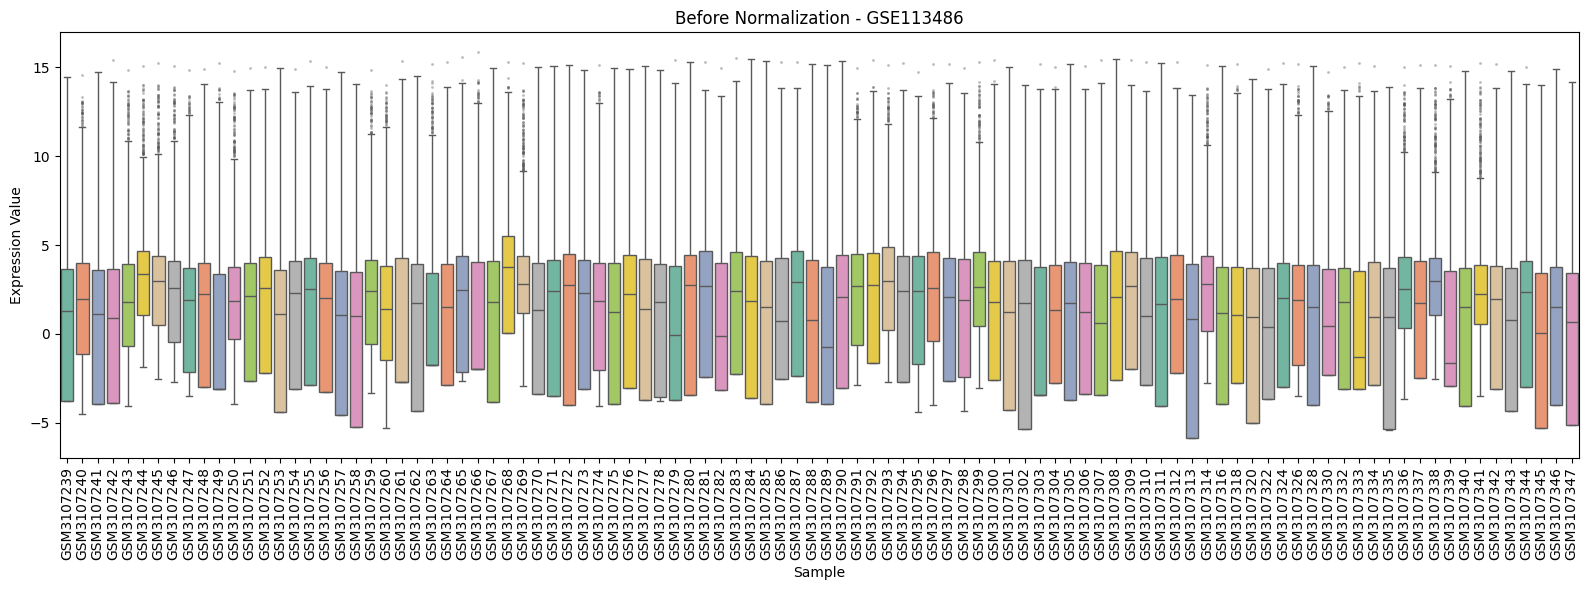

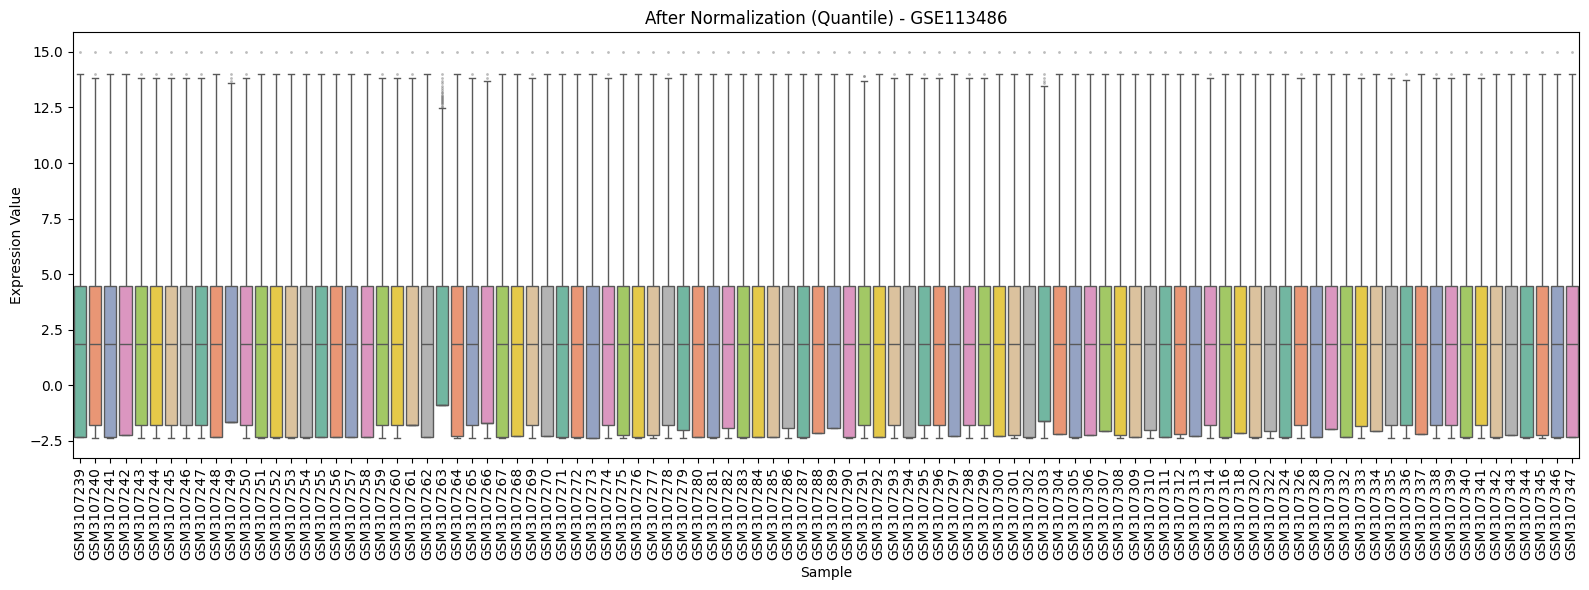

In [4]:
# Data preprocess of GSE113486
import GEOparse
import os
import pandas as pd
import warnings
import logging
from sklearn.preprocessing import quantile_transform, minmax_scale, StandardScaler, robust_scale
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=SyntaxWarning)
logging.getLogger("GEOparse").setLevel(logging.CRITICAL)
import os
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")
GEO_ID = "GSE113486"
base_path = "D:/MSc Genetic/Master thesis/coding/GEO_Data/"
filename = f"{GEO_ID}_family.soft.gz"
filepath = base_path + filename
if not os.path.exists(filepath):
    raise FileNotFoundError(f"File not found: {filepath}")
gse = GEOparse.get_GEO(filepath=filepath)
# Xử lý Phenotype
pheno_data = pd.DataFrame([gsm.metadata for gsm in gse.gsms.values()])
pheno_data.to_excel ("GSE113486.xlsx", index=True)
pheno_data["title"] = pheno_data["title"].apply(lambda x: x[0] if isinstance(x, list) else x)
pheno_data["geo_accession"] = pheno_data["geo_accession"].apply(lambda x: x[0] if isinstance(x, list) else x)
# Hàm dán nhãn theo yêu cầu cụ thể 
def label_logic(title):
    # Kiểm tra nhóm No cancer (dựa trên từ khóa Non-cancer)
    if "Non-cancer" in title:
        return "No cancer"
    # Kiểm tra nhóm CRC (dựa trên Colorectal Cancer hoặc mã CC)
    elif "Colorectal Cancer" in title or "[CC" in title:
        return "CRC"
    else:
        return "Other"

pheno_data["type"] = pheno_data["title"].str.extract(r"\s(.+)")
pheno_data["type"] = pheno_data.apply(
    lambda row: row["title"].rsplit(" ", 1)[0] if pd.isna(row["type"]) or any(char.isdigit() for char in str(row["type"])) else row["type"],
    axis=1
)
pheno_data_filtered = pheno_data[["type", "geo_accession"]]
pheno_data_filtered.set_index("geo_accession", inplace=True)
pheno_data_filtered.index.name = None

# Thống kê sau khi dán nhãn
print(f"Phenotype Summary for {GEO_ID}")
print("-------------------------------------------------------")
disease_counts = pheno_data_filtered["type"].value_counts()
disease_percentages = (disease_counts / disease_counts.sum()) * 100
summary = pd.DataFrame({
    "Count": disease_counts,
    "Percentage (%)": (disease_counts / disease_counts.sum() * 100).round(2)})
print(f"Phenotype Summary for {GEO_ID}")
print(summary)
print("-------------------------------------------------------")

target_diseases = ["Non-cancer control", "Colorectal Cancer"] # Replace by your Cancer type of interest
pheno_data_filtered = pheno_data_filtered[
    pheno_data_filtered["type"].isin(target_diseases)]
print("Filtered Samples")
print(pheno_data_filtered)
print("-------------------------------------------------------")
gene_anno = gse.gpls[list(gse.gpls.keys())[0]].table[["ID", "miRNA_ID_LIST"]].dropna()
gene_anno.set_index("ID", inplace=True)
gene_anno.index.name = None
print("Gene Annotation")
print(gene_anno.iloc[:5])
print("-------------------------------------------------------")
#  Extract Expression Data
expression_data = gse.pivot_samples('VALUE').T
expression_data.index.name = None
expression_data = expression_data.dropna(axis=1, how='any')  # Drop genes with missing values
print("Raw Expression Data")
print(expression_data.iloc[:5, :5])
print("-------------------------------------------------------")
#  Merge Expression with Phenotype
expression_pheno_data = pd.merge(pheno_data_filtered, expression_data, left_index=True, right_index=True)
df = expression_pheno_data.rename(columns={"type": "type"})
label_map = {disease: i for i, disease in enumerate(target_diseases)}
df["type"] = df["type"].apply(lambda x: label_map.get(x, x))
print("Unnormalized Expression Data")
print(df.iloc[:-5, :5])
print("-------------------------------------------------------")

# ------------------------------------------------------------------------------------------------------------------------
#normalization
from rpy2.robjects import pandas2ri, r, globalenv
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
import pandas as pd
expression_df = df.drop(columns=["type"])
expression_df_t = expression_df.T  # R expects samples as columns
with localconverter(default_converter + pandas2ri.converter):
    expr_r = pandas2ri.py2rpy(expression_df_t)
r("library(limma)")
globalenv["expr_r"] = expr_r
r("expr_norm <- normalizeBetweenArrays(expr_r, method='quantile')")
expr_norm_r = r("expr_norm")
with localconverter(default_converter + pandas2ri.converter):
    normalized_df = pandas2ri.rpy2py(expr_norm_r)
normalized_df = pd.DataFrame(normalized_df, index=expression_df.columns, columns=expression_df.index).T
normalized_df["type"] = df["type"]
# ĐỒNG BỘ: Đổi tên cột nhãn thành 'target' và đẩy lên đầu
normalized_df = normalized_df.rename(columns={"type": "target"})
cols = ['target'] + [col for col in normalized_df.columns if col != 'target']
normalized_df = normalized_df[cols]
# ------------------------------------------------------------------------------------------------------------------------

# Display result
# Hiển thị kết quả kiểm tra cấu trúc
print("Normalized Expression Data (GSE113486) - Đã đồng bộ:")
print(f"Kích thước: {normalized_df.shape}")
print(normalized_df['target'].value_counts()) # Phải hiển thị số lượng nhãn 0 và 1

# Xuất file phục vụ việc GỘP DATABASE
output_file_path = "D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/GSE113486_ready_to_merge.txt"
normalized_df.to_csv(output_file_path, sep='\t', index=True)
print(f"[THÀNH CÔNG] Đã xuất file tại: {output_file_path}")

# Boxplot Normalisation Visualise
top_50_samples = expression_df.index[:100]

# Melt bảng trước chuẩn hóa
expression_long = expression_df.loc[top_50_samples].melt(ignore_index=False, var_name="miRNA", value_name="expression")
expression_long["sample"] = expression_long.index

# ĐỒNG BỘ: Sửa drop(columns=["type"]) thành drop(columns=["target"])
normalized_long = normalized_df.loc[top_50_samples].drop(columns=["target"]).melt(ignore_index=False, var_name="miRNA", value_name="expression")
normalized_long["sample"] = normalized_long.index

flier_props = dict(marker='o', markersize=1, linestyle='none', alpha=0.4, color='black')
## Vẽ biểu đồ TRƯỚC chuẩn hóa
plt.figure(figsize=(16, 6))
sns.boxplot(x="sample", y="expression", palette="Set2", data=expression_long, flierprops=flier_props)
plt.title(f"Before Normalization - {GEO_ID}")
plt.xlabel("Sample")
plt.ylabel("Expression Value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Vẽ biểu đồ SAU chuẩn hóa Quantile
plt.figure(figsize=(16, 6))
sns.boxplot(x="sample", y="expression", palette="Set2", data=normalized_long, flierprops=flier_props)
plt.title(f"After Normalization (Quantile) - {GEO_ID}")
plt.xlabel("Sample")
plt.ylabel("Expression Value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Bảng tóm tắt mẫu sau khi dán nhãn từ characteristics :
           Count  Percentage (%)
type                            
Other       8951           55.29
No cancer   5643           34.85
CRC         1596            9.86
Filtered Samples
                    type
geo_accession           
GSM6484678           CRC
GSM6484679           CRC
GSM6484680           CRC
GSM6484681           CRC
GSM6484682           CRC
...                  ...
GSM6499356     No cancer
GSM6499357     No cancer
GSM6499358     No cancer
GSM6499359     No cancer
GSM6499360     No cancer

[7239 rows x 1 columns]
-------------------------------------------------------
Gene Annotation
              miRNA_ID_LIST
MIMAT0000062  hsa-let-7a-5p
MIMAT0000063  hsa-let-7b-5p
MIMAT0000064  hsa-let-7c-5p
MIMAT0000065  hsa-let-7d-5p
MIMAT0000066  hsa-let-7e-5p
miRNA_ID_LIST  
hsa-miR-99b-5p     1
hsa-let-7a-2-3p    1
hsa-let-7a-3p      1
hsa-let-7a-5p      1
hsa-let-7b-3p      1
                  ..
hsa-let-7d-5p      1
hsa-let-7e

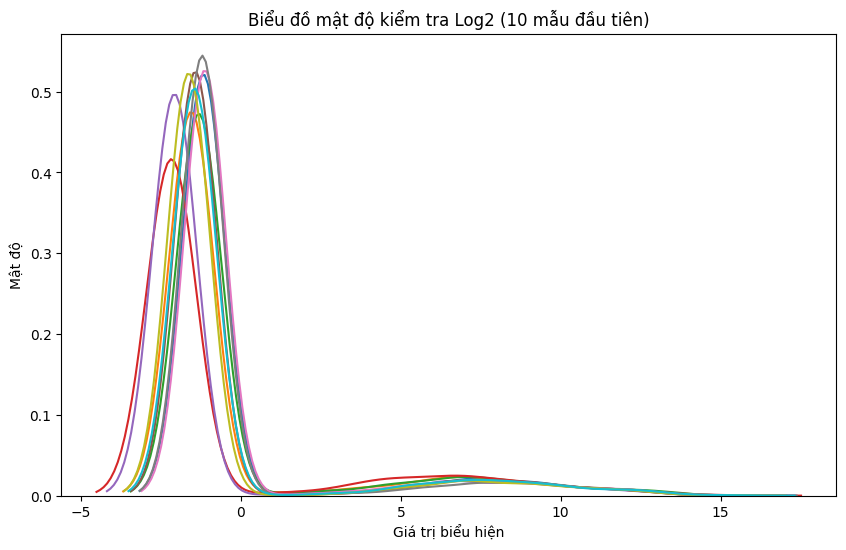

Giá trị biểu hiện lớn nhất là: 19.21913709
=> Kết luận: Dữ liệu có vẻ ĐÃ được Log2.
--- Kết quả Merge thành công ---
Tổng số mẫu sau khi gộp: 16190
Số lượng miRNA: 2565
         type  type_numeric
BC0010  Other           NaN
BC0011  Other           NaN
BC0016  Other           NaN
BC0025  Other           NaN
BC0033  Other           NaN
--- Thống kê mẫu sau khi lọc sạch dữ liệu ---
type
No cancer    5643
CRC          1596
Name: count, dtype: int64
Tổng số mẫu còn lại: 7239
-------------------------------------------------------
Kích thước ma trận đưa vào R: (2565, 7239)
Cấu trúc file GSE211692 sau đồng bộ:
Kích thước: (7239, 2566)
target
0    5643
1    1596
Name: count, dtype: int64
[THÀNH CÔNG] Đã lưu file tại: D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/GSE211692_ready_to_merge.txt


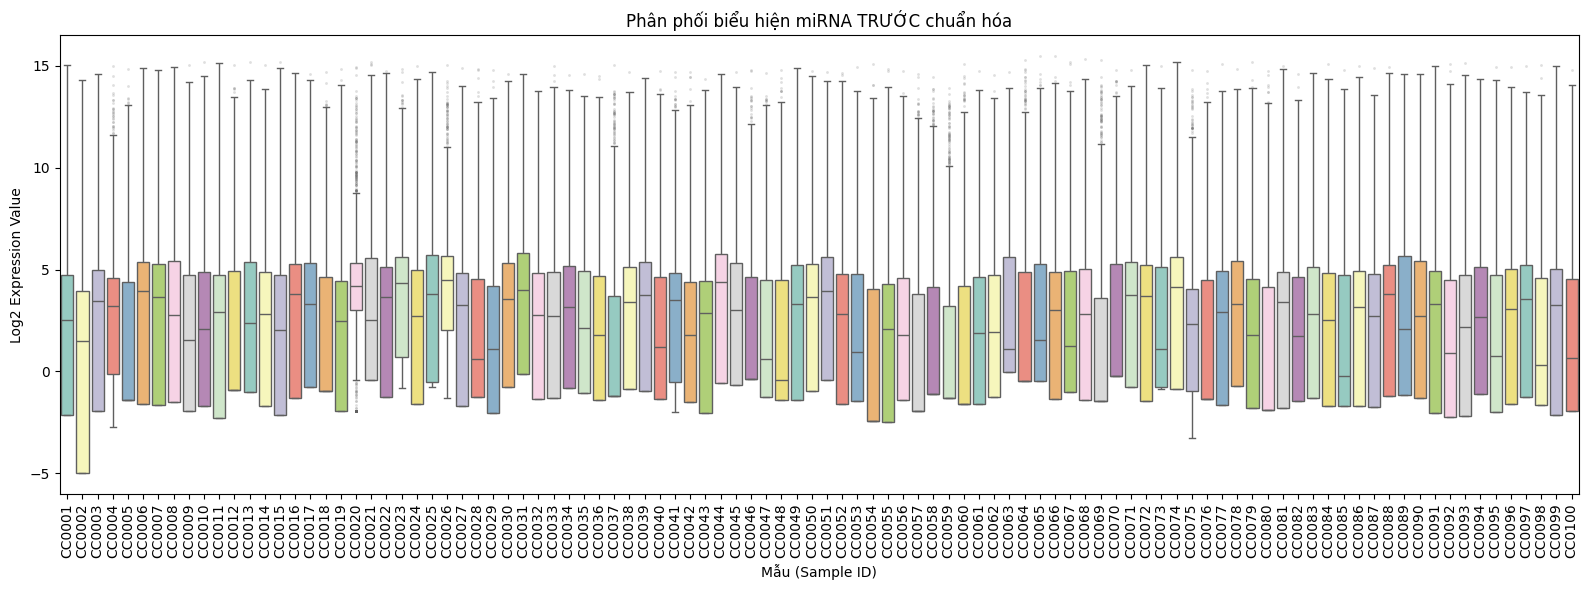

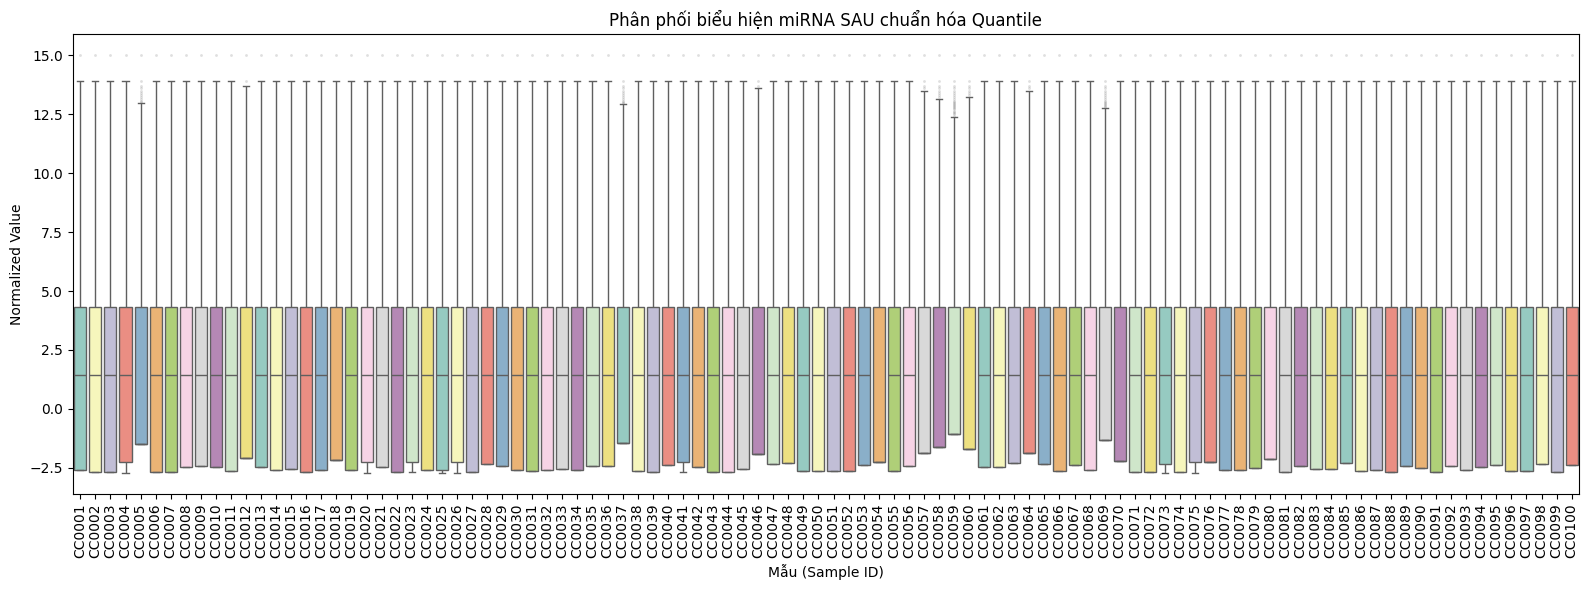

In [5]:
#Data preprocess of GSE211692
import GEOparse
import os
import pandas as pd
import warnings
import logging
from sklearn.preprocessing import quantile_transform, minmax_scale, StandardScaler, robust_scale
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=SyntaxWarning)
logging.getLogger("GEOparse").setLevel(logging.CRITICAL)
import os
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")
# 1. THIẾT LẬP ĐƯỜNG DẪN
GEO_ID = "GSE211692"
base_path = "D:/MSc Genetic/Master thesis/coding/GEO_Data/"
filename = f"{GEO_ID}_family.soft.gz"
filepath = base_path + filename
if not os.path.exists(filepath):
    raise FileNotFoundError(f"File not found: {filepath}")
gse = GEOparse.get_GEO(filepath=filepath)
# Xử lý Phenotype
pheno_data = pd.DataFrame([gsm.metadata for gsm in gse.gsms.values()])
pheno_data["title"] = pheno_data["title"].apply(lambda x: x[0] if isinstance(x, list) else x)
pheno_data["geo_accession"] = pheno_data["geo_accession"].apply(lambda x: x[0] if isinstance(x, list) else x)
# 2. Dán nhãn loại bệnh dựa trên cột characteristics_ch1:
# hàm bổ trợ để trích xuất giá trị từ danh sách characteristics
def get_val_from_list(char_list, key_name):
    if not isinstance(char_list, list):
        return "Unknown"
    for item in char_list:
        # Chuyển về chữ thường để so sánh không phân biệt hoa thường
        if key_name.lower() in item.lower():
            try:
                # Tách lấy phần giá trị sau dấu ": "
                return item.split(": ")[1].strip()
            except IndexError:
                return "Unknown"
    return "Unknown"
#Tạo cột tạm thời 'disease_state' bằng cách trích xuất từ characteristics_ch1
# GEOparse lưu cột này là 'characteristics_ch1'
pheno_data["disease_state"] = pheno_data["characteristics_ch1"].apply(
    lambda x: get_val_from_list(x, "disease state")
)
#Dán nhãn chuẩn theo yêu cầu của bạn
def map_labels(state):
    state_lower = state.lower()
    if state_lower == "no cancer":
        return "No cancer"
    elif state_lower == "colorectal cancer":
        return "CRC"
    else:
        return "Other"

pheno_data["type"] = pheno_data["disease_state"].apply(map_labels)
# Cập nhập lại Dataframe lọc:
pheno_data_filtered = pheno_data[["type", "geo_accession"]]
pheno_data_filtered.set_index("geo_accession", inplace=True)
# In kết quả kiểm tra
disease_counts = pheno_data_filtered["type"].value_counts()
summary = pd.DataFrame({
    "Count": disease_counts,
    "Percentage (%)": (disease_counts / disease_counts.sum() * 100).round(2)
})
print("Bảng tóm tắt mẫu sau khi dán nhãn từ characteristics :")
print(summary)
target_diseases = ["No cancer", "CRC"] # Replace by your Cancer type of interest
pheno_data_filtered = pheno_data_filtered[
    pheno_data_filtered["type"].isin(target_diseases)]
print("Filtered Samples")
print(pheno_data_filtered)
print("-------------------------------------------------------")
# 3. EXTRACT GENE ANNOTATION:
# Lấy bảng Annotation từ GPL đầu tiên trong GSE
gpl = gse.gpls['GPL21263']
gene_anno = gpl.table[['ID', 'miRNA_ID_LIST']].dropna()
gene_anno.set_index("ID", inplace=True)
gene_anno.index.name = None
gene_anno_count = gene_anno.value_counts()
print("Gene Annotation")
print(gene_anno.iloc[:5])
print (gene_anno_count)
print("-------------------------------------------------------")
# tải tệp GSE211692_normalized_miRNA_expression.csv.gz để đọc xuất dữ liệu biểu hiện
processed_file = "D:/MSc Genetic/Master thesis/coding/GEO_Data/GSE211692_processed_data_matrix.txt.gz"
# Đọc ma trận dữ liệu (thường file .txt này dùng dấu Tab làm phân cách)
expression_df = pd.read_csv(processed_file, sep='\t', index_col=0)
# Chuyển đổi để Mẫu thành dòng, miRNA thành cột phục vụ ML
expression_data = expression_df.T
print("Đã tải ma trận dữ liệu biểu hiện thành công!")
print(f"Kích thước ma trận: {expression_data.shape}")
import numpy as np

# Vẽ biểu đồ mật độ cho 10 mẫu đầu tiên để kiểm tra nhanh
plt.figure(figsize=(10, 6))
for i in range(10):
    sns.kdeplot(expression_data.iloc[i, :])

plt.title("Biểu đồ mật độ kiểm tra Log2 (10 mẫu đầu tiên)")
plt.xlabel("Giá trị biểu hiện")
plt.ylabel("Mật độ")
plt.show()
# Kiểm tra giá trị lớn nhất
max_val = expression_data.max().max()
print(f"Giá trị biểu hiện lớn nhất là: {max_val}")

if max_val > 50:
    print("=> Kết luận: Dữ liệu CÓ THỂ chưa Log2. Bạn nên thực hiện np.log2(expression_data + 1)")
else:
    print("=> Kết luận: Dữ liệu có vẻ ĐÃ được Log2.")
#4. Merge Expression with Phenotype
#Chuẩn bị lại bảng Phenotype để dùng 'title' làm Index khớp với file CSV
# Lưu ý: pheno_data là bảng gốc bạn đã xử lý dán nhãn ở các bước trước
pheno_for_merge = pheno_data[["title", "type"]].copy()
pheno_for_merge.set_index("title", inplace=True)
pheno_for_merge.index.name = None
#Thực hiện Merge
# expression_data của bạn hiện đang có index là các mã CHC/CC khớp với pheno_for_merge
expression_pheno_data = pd.merge(pheno_for_merge, expression_data, left_index=True, right_index=True)
#Tạo biến df cuối cùng và mã hóa nhãn nhị phân (0 và 1)
df = expression_pheno_data.copy()
label_map = {"No cancer": 0, "CRC": 1}
df["type_numeric"] = df["type"].map(label_map)
# Đưa cột nhãn lên đầu để dễ quan sát
cols = ["type", "type_numeric"] + [c for c in df.columns if c not in ["type", "type_numeric"]]
df = df[cols]

print("--- Kết quả Merge thành công ---")
print(f"Tổng số mẫu sau khi gộp: {df.shape[0]}")
print(f"Số lượng miRNA: {df.shape[1] - 2}")
print(df[["type", "type_numeric"]].head())
#Lọc chỉ giữ lại CRC và No cancer
# Loại bỏ tất cả các dòng có nhãn 'Other' hoặc nhãn không xác định
df_final = df[df['type'].isin(['CRC', 'No cancer'])].copy()
# Kiểm tra lại số lượng mẫu sau khi lọc
print("--- Thống kê mẫu sau khi lọc sạch dữ liệu ---")
print(df_final['type'].value_counts())
print(f"Tổng số mẫu còn lại: {df_final.shape[0]}")
print("-------------------------------------------------------")
#5. bắt đầu Normalization
# 5.1. Tách riêng bảng biểu hiện (loại bỏ cột 'type' và 'type_numeric')
expression_df = df_final.drop(columns=["type", "type_numeric"])
# 5.2. Chuyển vị ma trận (R expects samples as columns)
expression_df_t = expression_df.T 
print(f"Kích thước ma trận đưa vào R: {expression_df_t.shape}") # (Số miRNA x Số mẫu)

from rpy2.robjects import pandas2ri, r, globalenv
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
# Chỉ giữ lại CRC (1) và No cancer (0) để tránh nhiễu
df_clean = df.dropna(subset=['type_numeric']).copy()

# Tách ma trận biểu hiện
expression_df = df_clean.drop(columns=["type", "type_numeric"])
expression_df_t = expression_df.T  # Chuyển vị: R yêu cầu mẫu ở cột
# Không cần pandas2ri.activate(), localconverter sẽ tự xử lý
with localconverter(default_converter + pandas2ri.converter):
    expr_r = pandas2ri.py2rpy(expression_df_t)
r("library(limma)")
globalenv["expr_r"] = expr_r
# Thực hiện chuẩn hóa Quantile
r("expr_norm <- normalizeBetweenArrays(expr_r, method='quantile')")
expr_norm_r = r("expr_norm")
#5.3. Chuyển kết quả ngược lại Python
with localconverter(default_converter + pandas2ri.converter):
    normalized_matrix = pandas2ri.rpy2py(expr_norm_r)
# Đưa về định dạng DataFrame (Mẫu là dòng, miRNA là cột)
normalized_df = pd.DataFrame(normalized_matrix, 
                             index=expression_df_t.index, 
                             columns=expression_df_t.columns).T

# Đồng bộ cột nhãn thành 'target' và lấy giá trị nhị phân từ df_clean cũ
# Vì df_clean trước đó của bà đã mã hóa type_numeric (0, 1) rồi nên chỉ cần gán qua:
normalized_df["target"] = df_clean["type_numeric"].astype(int)
# Sắp xếp lại cột nhãn lên đầu
cols = ['target'] + [col for col in normalized_df.columns if col != 'target']
normalized_df = normalized_df[cols]
# Hiển thị kết quả kiểm tra
print("Cấu trúc file GSE211692 sau đồng bộ:")
print(f"Kích thước: {normalized_df.shape}")
print(normalized_df['target'].value_counts())

# Lưu kết quả vào thư mục làm việc của bạn
# Đổi tên file để phản ánh đúng dataset GSE211692 và đối tượng nghiên cứu CRC
output_filename = "D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/GSE211692_ready_to_merge.txt"
normalized_df.to_csv(output_filename, sep='\t', index=True)
print(f"[THÀNH CÔNG] Đã lưu file tại: {output_filename}")

#6. BOXPLOT NORMALISATION VISUALISE

# Vì số lượng mẫu cực lớn (16,190), chúng ta chỉ chọn 40 mẫu đầu tiên để vẽ biểu đồ cho rõ ràng
sample_subset = expression_df.index[:100] 

# Chuẩn bị dữ liệu Long-format cho biểu đồ TRƯỚC chuẩn hóa
expression_long = expression_df.loc[sample_subset].melt(ignore_index=False, var_name="miRNA", value_name="expression")
expression_long["sample"] = expression_long.index

# Chuẩn bị dữ liệu Long-format cho biểu đồ SAU chuẩn hóa
# Loại bỏ cột 'type' trước khi melt
normalized_long = normalized_df.loc[sample_subset].drop(columns=["target"]).melt(ignore_index=False, var_name="miRNA", value_name="expression")
normalized_long["sample"] = normalized_long.index

# Cấu hình hiển thị các điểm outlier (nhiễu) nhỏ lại để biểu đồ thoáng hơn
flier_props = dict(marker='o', markersize=1, linestyle='none', alpha=0.2, color='black')
#6.1. Vẽ biểu đồ TRƯỚC khi chuẩn hóa
plt.figure(figsize=(16, 6))
sns.boxplot(x="sample", y="expression", palette="Set3", data=expression_long, flierprops=flier_props)
plt.title("Phân phối biểu hiện miRNA TRƯỚC chuẩn hóa")
plt.xlabel("Mẫu (Sample ID)")
plt.ylabel("Log2 Expression Value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
#6.2. Vẽ biểu đồ SAU khi chuẩn hóa Quantile
plt.figure(figsize=(16, 6))
sns.boxplot(x="sample", y="expression", palette="Set3", data=normalized_long, flierprops=flier_props)
plt.title("Phân phối biểu hiện miRNA SAU chuẩn hóa Quantile")
plt.xlabel("Mẫu (Sample ID)")
plt.ylabel("Normalized Value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Phenotype Summary for GSE106817
                          Count  Percentage (%)
type                                           
non-Cancer                 2759           68.19
Ovarian Cancer              320            7.91
Gastric Cancer              115            2.84
Colorectal Cancer           115            2.84
Breast Cancer               115            2.84
Sarcoma                     115            2.84
Lung Cancer                 115            2.84
Pancreatic Cancer           115            2.84
Esophageal Cancer            88            2.17
Hepatocellular Carcinoma     81            2.00
Borderline Ovarian Tumor     66            1.63
Benign Ovarian Disease       29            0.72
OV_others                    13            0.32
-------------------------------------------------------
Filtered Samples
                         type
GSM2850824  Colorectal Cancer
GSM2850825  Colorectal Cancer
GSM2850826  Colorectal Cancer
GSM2850827  Colorectal Cancer
GSM2850828  Colorectal Ca

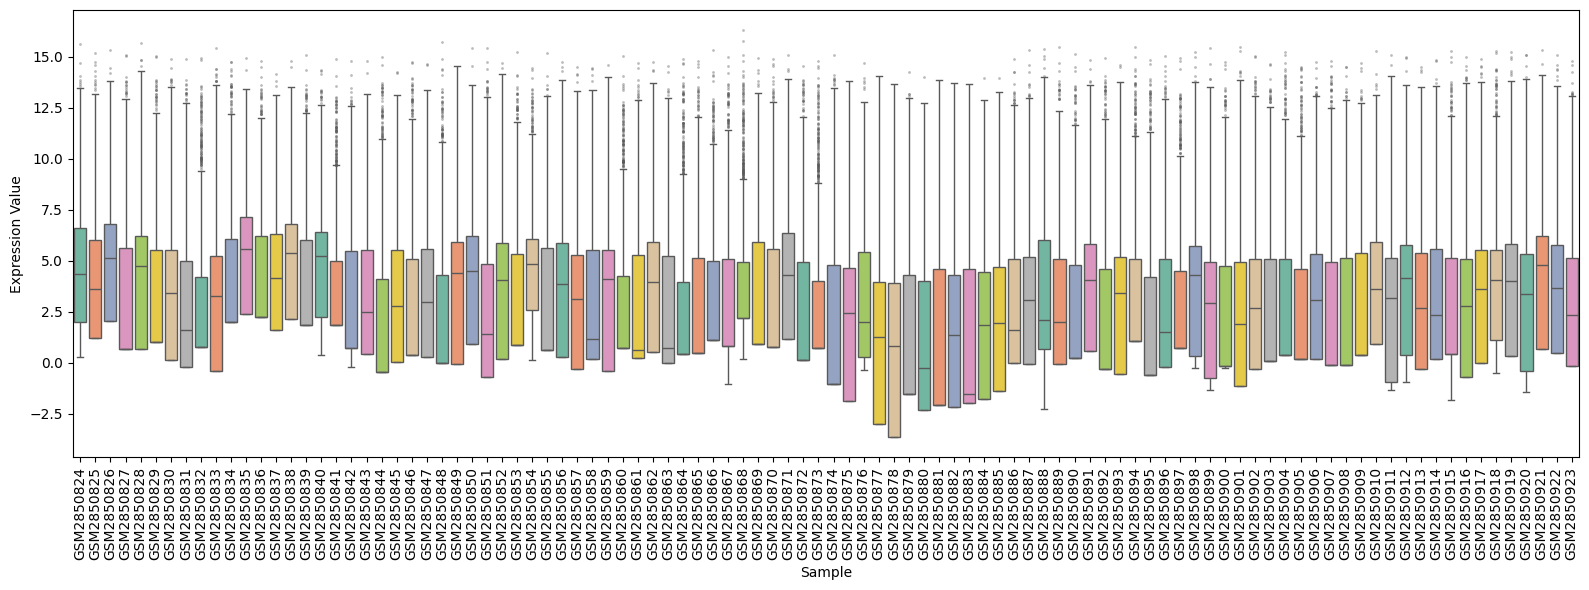

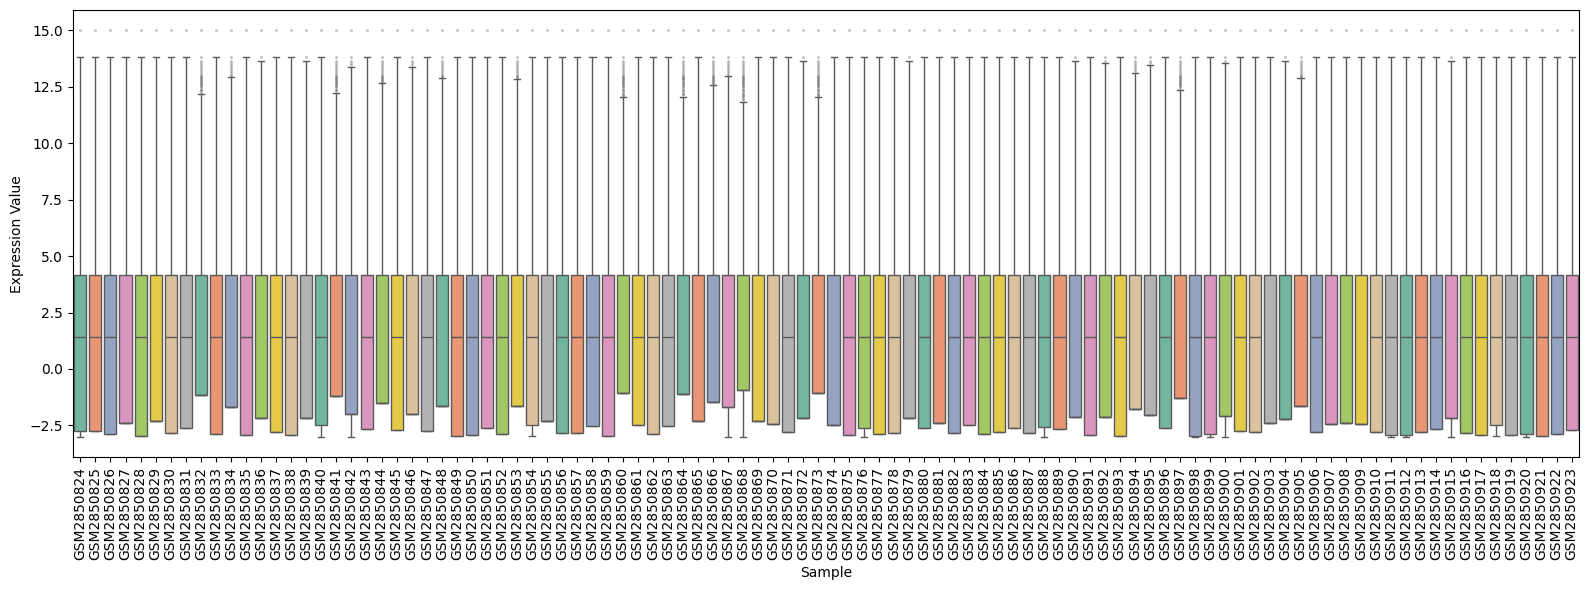

In [6]:
# Data preprocess of GSE106817
import GEOparse
import os
import pandas as pd
import warnings
import logging
from sklearn.preprocessing import quantile_transform, minmax_scale, StandardScaler, robust_scale
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore", category=SyntaxWarning)
logging.getLogger("GEOparse").setLevel(logging.CRITICAL)
import os
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")
GEO_ID = "GSE106817"
base_path = "D:/MSc Genetic/Master thesis/coding/GEO_Data/"
filename = f"{GEO_ID}_family.soft.gz"
filepath = base_path + filename
if not os.path.exists(filepath):
    raise FileNotFoundError(f"File not found: {filepath}")
gse = GEOparse.get_GEO(filepath=filepath)
pheno_data = pd.DataFrame([gsm.metadata for gsm in gse.gsms.values()])
pheno_data.to_excel ("GSE106817.xlsx", index=True)
pheno_data["title"] = pheno_data["title"].apply(lambda x: x[0] if isinstance(x, list) else x)
pheno_data["geo_accession"] = pheno_data["geo_accession"].apply(lambda x: x[0] if isinstance(x, list) else x)
pheno_data["type"] = pheno_data["title"].str.extract(r"\s(.+)")
pheno_data["type"] = pheno_data.apply(
    lambda row: row["title"].rsplit(" ", 1)[0] if pd.isna(row["type"]) or any(char.isdigit() for char in str(row["type"])) else row["type"],
    axis=1
)
pheno_data_filtered = pheno_data[["type", "geo_accession"]]
pheno_data_filtered.set_index("geo_accession", inplace=True)
pheno_data_filtered.index.name = None
#  Summary of Disease Types
disease_counts = pheno_data_filtered["type"].value_counts()
disease_percentages = (disease_counts / disease_counts.sum()) * 100
summary = pd.DataFrame({
    "Count": disease_counts,
    "Percentage (%)": disease_percentages.round(2)})
print(f"Phenotype Summary for {GEO_ID}")
print(summary)
print("-------------------------------------------------------")
target_diseases = ["non-Cancer", "Colorectal Cancer"]
pheno_data_filtered = pheno_data_filtered[
    pheno_data_filtered["type"].isin(target_diseases)
]
print("Filtered Samples")
print(pheno_data_filtered)
print("-------------------------------------------------------")
#  Extract Gene Annotation
gene_anno = gse.gpls[list(gse.gpls.keys())[0]].table[["ID", "miRNA_ID_LIST"]].dropna()
gene_anno.set_index("ID", inplace=True)
gene_anno.index.name = None
print("Gene Annotation")
print(gene_anno.iloc[:5])
print("-------------------------------------------------------")
#  Extract Expression Data
expression_data = gse.pivot_samples('VALUE').T
expression_data.index.name = None
expression_data = expression_data.dropna(axis=1, how='any')  # Drop genes with missing values
print("Raw Expression Data")
print(expression_data.iloc[:5, :5])
print("-------------------------------------------------------")
#  Merge Expression with Phenotype
expression_pheno_data = pd.merge(pheno_data_filtered, expression_data, left_index=True, right_index=True)
df = expression_pheno_data.rename(columns={"type": "type"})
label_map = {disease: i for i, disease in enumerate(target_diseases)}
df["type"] = df["type"].apply(lambda x: label_map.get(x, x))
print("Unnormalized Expression Data")
print(df.iloc[:-5, :5])
print("-------------------------------------------------------")

# ------------------------------------------------------------------------------------------------------------------------
from rpy2.robjects import pandas2ri, r, globalenv
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
import pandas as pd

# Bước 1: Chuẩn bị dữ liệu
expression_df = df.drop(columns=["type"])
expression_df_t = expression_df.T  # R expects samples as columns

# Bước 2: Chuyển sang R
with localconverter(default_converter + pandas2ri.converter):
    expr_r = pandas2ri.py2rpy(expression_df_t)

# Bước 3: Load thư viện limma và chuẩn hóa
r("library(limma)")
globalenv["expr_r"] = expr_r
r("expr_norm <- normalizeBetweenArrays(expr_r, method='quantile')")
#r("expr_norm <- t(scale(t(expr_norm)))") # Optional: z-score after quantile normalization
# Bước 4: Chuyển lại về Python
expr_norm_r = r("expr_norm")
with localconverter(default_converter + pandas2ri.converter):
    normalized_df = pandas2ri.rpy2py(expr_norm_r)

# Bước 5: Tạo lại DataFrame chuẩn hóa
normalized_df = pd.DataFrame(normalized_df, index=expression_df.columns, columns=expression_df.index).T
normalized_df["type"] = df["type"]
cols = ['type'] + [col for col in normalized_df.columns if col != 'type']
normalized_df = normalized_df[cols]
# Display result
print("Normalized Expression Data using limma::normalizeBetweenArrays()")
print(normalized_df.iloc[:5, :5])
normalized_df.to_csv("GSE106817_Quantile_Z_Full_Probe.txt", sep='\t', index=True)

# ------------------------------------------------------------------------------------------------------------------------

# Boxplot Normalization Visualise
top_50_samples = expression_df.index[:100]
expression_long = expression_df.loc[top_50_samples].melt(ignore_index=False, var_name="miRNA", value_name="expression")
expression_long["sample"] = expression_long.index
normalized_long = normalized_df.loc[top_50_samples].drop(columns=["type"]).melt(ignore_index=False, var_name="miRNA", value_name="expression")
normalized_long["sample"] = normalized_long.index
flier_props = dict(marker='o', markersize=1, linestyle='none', alpha=0.4, color='black')  
plt.figure(figsize=(16, 6))
sns.boxplot(x="sample", y="expression", palette= "Set2", data=expression_long, flierprops=flier_props)

plt.xlabel("Sample")
plt.ylabel("Expression Value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
plt.figure(figsize=(16, 6))
sns.boxplot(x="sample", y="expression", palette= "Set2", data=normalized_long, flierprops=flier_props)

plt.xlabel("Sample")
plt.ylabel("Expression Value")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [7]:
# Data preprocess of GSE180202
import GEOparse
import os
import pandas as pd
import warnings
import logging
from sklearn.preprocessing import quantile_transform, minmax_scale, StandardScaler, robust_scale
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore", category=SyntaxWarning)
logging.getLogger("GEOparse").setLevel(logging.CRITICAL)
# Cấu hình đường dẫn
import os
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")
GEO_ID = "GSE180202"
base_path = "D:/MSc Genetic/Master thesis/coding/GEO_Data/"
filename = f"{GEO_ID}_family.soft.gz"
filepath = base_path + filename
if not os.path.exists(filepath):
    raise FileNotFoundError(f"File not found: {filepath}")
# Load file SOFT
gse = GEOparse.get_GEO(filepath=filepath)
pheno_data = pd.DataFrame([gsm.metadata for gsm in gse.gsms.values()])
pheno_data["title"] = pheno_data["title"].apply(lambda x: x[0] if isinstance(x, list) else x)
pheno_data["geo_accession"] = pheno_data["geo_accession"].apply(lambda x: x[0] if isinstance(x, list) else x)
pheno_data["type"] = pheno_data["title"].str.extract(r"\s(.+)")
pheno_data["type"] = pheno_data.apply(
    lambda row: row["title"].rsplit(" ", 1)[0] if pd.isna(row["type"]) or any(char.isdigit() for char in str(row["type"])) else row["type"],
    axis=1
)
pheno_data_filtered = pheno_data[["type", "geo_accession"]]
pheno_data_filtered.set_index("geo_accession", inplace=True)
pheno_data_filtered.index.name = None
#  Summary of Disease Types
disease_counts = pheno_data_filtered["type"].value_counts()
disease_percentages = (disease_counts / disease_counts.sum()) * 100
summary = pd.DataFrame({
    "Count": disease_counts,
    "Percentage (%)": disease_percentages.round(2)})
print(f"Phenotype Summary for {GEO_ID}")
print(summary)
print("-------------------------------------------------------")

# Lấy bảng Platform
platform_table = gse.gpls['GPL21576'].table
print("Các cột có trong Platform:", platform_table.columns.tolist())
#Hàm lấy tên miRNA chuẩn nhất (Ưu tiên GENE_SYMBOL của Agilent)
def get_best_mirna_name_v2(row):
    # Lấy các giá trị tiềm năng
    symbol = str(row.get('GENE_SYMBOL', ''))
    mir_id = str(row.get('miRNA_ID', ''))
    spot_id = str(row.get('SPOT_ID', ''))
    
    # Danh sách kiểm tra theo thứ tự ưu tiên
    candidates = [symbol, mir_id, spot_id]
    
    for cand in candidates:
        if 'hsa-' in cand.lower():
            # Làm sạch chuỗi: lấy phần tên miRNA chuẩn (ví dụ: hsa-miR-21)
            # Một số spot_id có thể là 'mir|hsa-miR-21|...'
            clean_name = cand.replace('mir|', '').split('|')[0]
            return clean_name
            
    return None

print("--- BƯỚC 1: KIỂM TRA DỮ LIỆU PLATFORM (V2) ---")
platform_table['Final_miRNA'] = platform_table.apply(get_best_mirna_name_v2, axis=1)
probe_map = platform_table.set_index('ID')['Final_miRNA'].to_dict()
valid_mirna_count = platform_table['Final_miRNA'].notnull().sum()
print(f"Số lượng Probe khớp được với tên miRNA (hsa-): {valid_mirna_count}")

# In ra để bạn check xem tên đã 'đẹp' chưa
print("\nCheck mapping thực tế từ SPOT_ID:")
print(platform_table[platform_table['Final_miRNA'].notnull()][['ID', 'SPOT_ID', 'Final_miRNA']].head(10))

#KHỞI TẠO data_dict VÀ labels_dict (BƯỚC BẠN ĐANG THIẾU)
print("--- ĐANG TRÍCH XUẤT NHÃN (LABELS) ---")
labels_dict = {}
for gsm_id, gsm in gse.gsms.items():
    source = str(gsm.metadata.get('source_name_ch1', [''])[0]).lower()
    chars = " ".join([str(i) for i in gsm.metadata.get('characteristics_ch1', [])]).lower()
    if "healthy" in source: label = "Healthy"
    elif "adenoma" in source: label = "Adenoma"
    elif "diverticulitis" in source: label = "Diverticulitis"
    elif "crc" in source:
        import re
        stage_match = re.search(r"stage\s+([ivx/l]+)", chars)
        label = f"CRC_Stage_{stage_match.group(1).upper()}" if stage_match else "CRC_Other"
    else: label = "Other"
    labels_dict[gsm_id] = label

print("--- 2. TRÍCH XUẤT BẢNG BIỂU HIỆN TỪ GỐC ---")
# Trong GSE180202, dữ liệu thường được lưu trữ trong gse.table nếu các GSM bị trống
try:
    # Thử lấy bảng tổng của toàn bộ GSE
    if hasattr(gse, 'table') and not gse.table.empty:
        expression_raw = gse.table.set_index('ID')
    else:
        # Nếu gse.table trống, ta buộc phải dùng bảng từ platform nếu nó chứa dữ liệu mẫu
        # Hoặc dùng phương pháp gom tụ các cột đơn lẻ
        all_series = []
        for gsm_id, gsm in gse.gsms.items():
            # Truy cập vào thuộc tính columns - nơi Agilent thường lưu dữ liệu thô
            if hasattr(gsm, 'columns') and not gsm.columns.empty:
                s = gsm.columns.iloc[:, 0] # Lấy cột dữ liệu đầu tiên
                s.name = gsm_id
                all_series.append(s)
        
        expression_raw = pd.concat(all_series, axis=1)

    print(f"Đã lấy được bảng dữ liệu: {expression_raw.shape}")

    # --- 3. MAPPING miRNA (Sử dụng probe_map 1142 miRNA đã tìm thấy) ---
    expression_raw.index = expression_raw.index.map(str)
    expression_raw.index = expression_raw.index.map(probe_map)
    
    # Loại bỏ probe không phải hsa-miRNA
    expression_raw = expression_raw[expression_raw.index.notnull()]
    
    # Gộp trung bình và xoay trục
    expression_final = expression_raw.groupby(level=0).mean().T
    
    # Dán nhãn Stage
    expression_final['type'] = pd.Series(labels_dict)

    print("\n" + "="*50)
    print("KẾT QUẢ CUỐI CÙNG CHO GSE180202:")
    print(f"Số lượng miRNA định danh: {expression_final.shape[1] - 1}")
    print(f"Tổng số mẫu: {expression_final.shape[0]}")
    print("\nThống kê các nhóm bệnh:")
    print(expression_final['type'].value_counts())

except Exception as e:
    print(f"LỖI PHÂN TÍCH: {e}")
    print("Gợi ý: Hãy thử dùng file Excel 'GSE180202_Quantile_Full_Probe.xlsx' bạn đã có.")

Phenotype Summary for GSE180202
                              Count  Percentage (%)
type                                               
healthy [HH Vb                   16           20.00
colorectal cancer_IV [HH Vb      16           20.00
colorectal cancer_III [HH Vb     16           20.00
diverticulitis [HH Vb             8           10.00
intestinal polyps [HH Vb          8           10.00
colorectal cancer_IIA [HH Vb      6            7.50
colorectal cancer_I [HH Vb        5            6.25
colorectal cancer_II [HH Vb       5            6.25
-------------------------------------------------------
Các cột có trong Platform: ['ID', 'miRNA_ID', 'SPOT_ID', 'GENE_SYMBOL', 'GENE_NAME', 'ACCESSION_STRING', 'CHROMOSOMAL_LOCATION', 'SPOT_ID.1']
--- BƯỚC 1: KIỂM TRA DỮ LIỆU PLATFORM (V2) ---
Số lượng Probe khớp được với tên miRNA (hsa-): 5893

Check mapping thực tế từ SPOT_ID:
                ID SPOT_ID     Final_miRNA
1   A_25_P00010019     NaN  hsa-miR-329-3p
2   A_25_P00010020     NaN  hs

Phenotype Summary for GSE112264
           Count  Percentage (%)
type                            
CRC           50           54.95
No cancer     41           45.05
-------------------------------------------------------
-> [OK] GSE112264: 91 mẫu, đã map probe và Z-score lưu tại D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/GSE112264_processed.txt


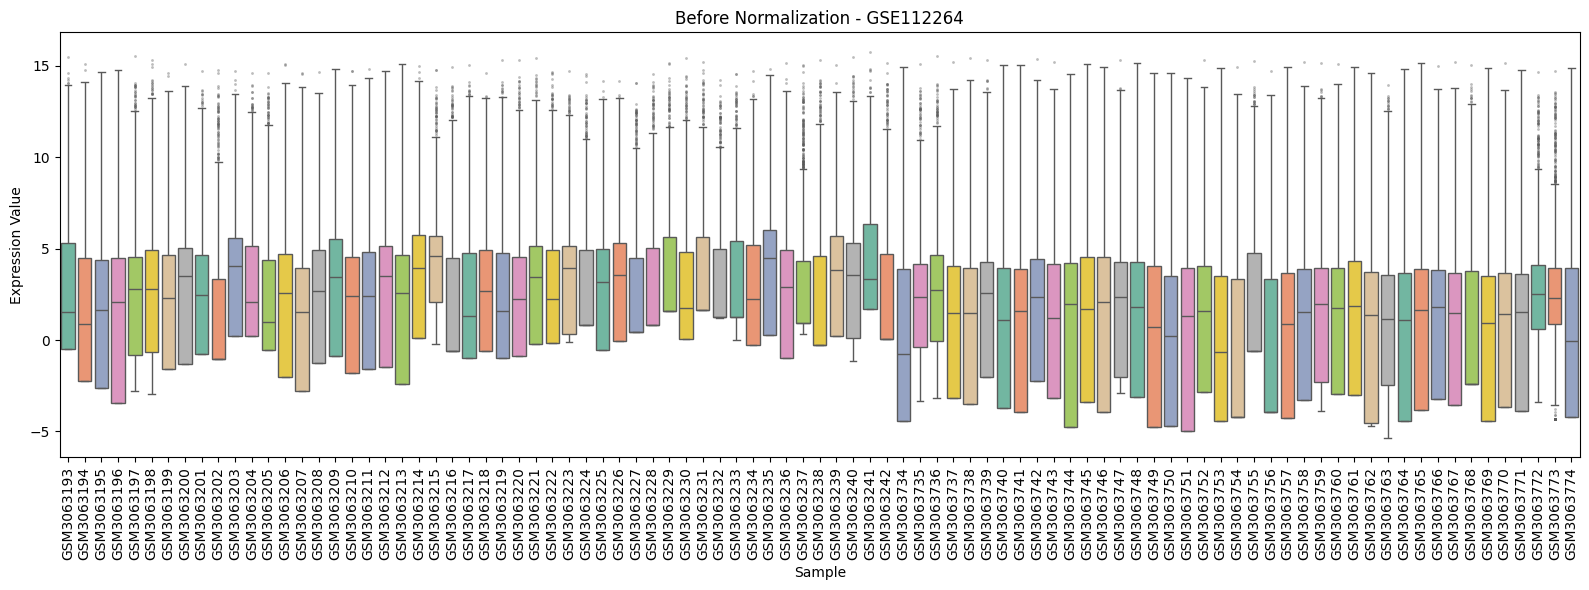

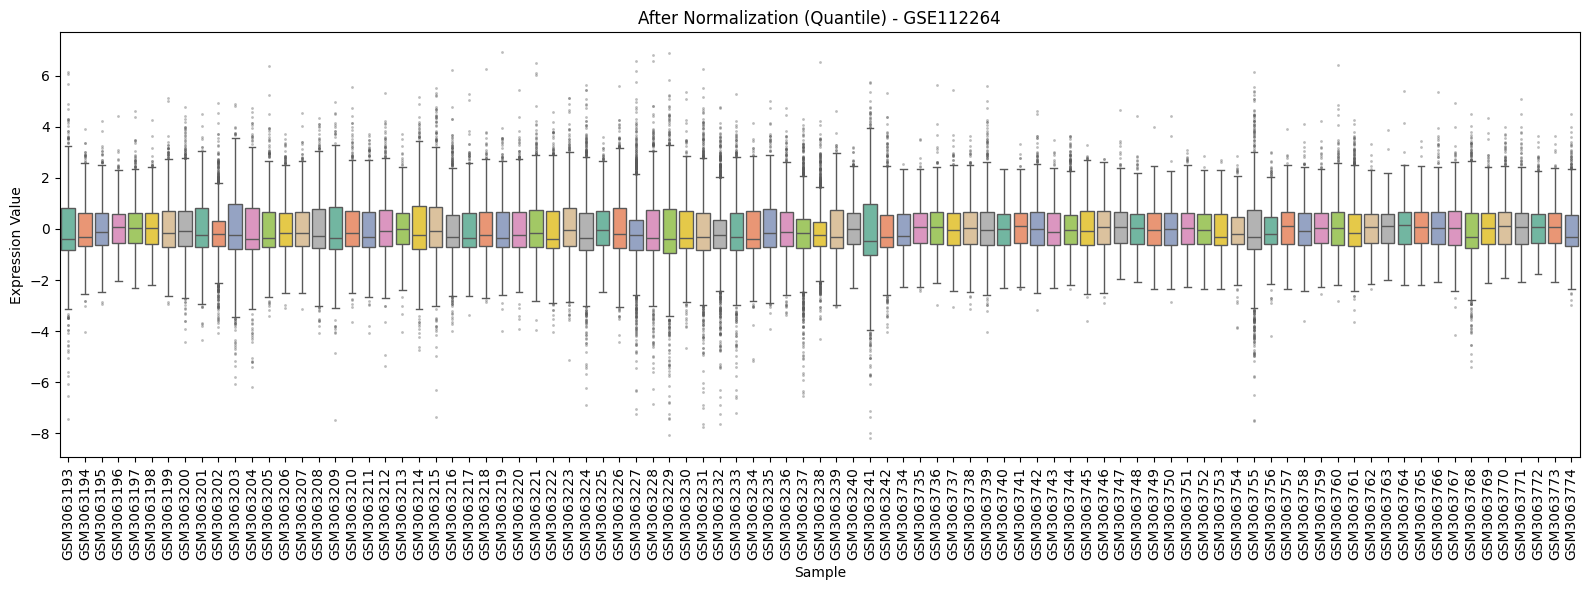

In [8]:
# Data preprocess of GSE112264
import GEOparse
import os
import pandas as pd
import warnings
import logging
from sklearn.preprocessing import quantile_transform, minmax_scale, StandardScaler, robust_scale
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore", category=SyntaxWarning)
logging.getLogger("GEOparse").setLevel(logging.CRITICAL)
import os
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")
GEO_ID = "GSE112264"
base_path = "D:/MSc Genetic/Master thesis/coding/GEO_Data/"
filepath = os.path.join(base_path, f"{GEO_ID}_family.soft.gz")
gse = GEOparse.get_GEO(filepath=filepath)

# 1. Xử lý Phenotype nhãn
pheno_data = pd.DataFrame([gsm.metadata for gsm in gse.gsms.values()])
pheno_data["title"] = pheno_data["title"].apply(lambda x: x[0] if isinstance(x, list) else x)
pheno_data["geo_accession"] = pheno_data["geo_accession"].apply(lambda x: x[0] if isinstance(x, list) else x)

# Tách loại bệnh từ tiêu đề
pheno_data["type"] = pheno_data["title"].str.extract(r"\s(.+)")
pheno_data["type"] = pheno_data.apply(
    lambda row: row["title"].rsplit(" ", 1)[0] if pd.isna(row["type"]) or any(char.isdigit() for char in str(row["type"])) else row["type"],
    axis=1
)

# Đồng bộ hóa chuỗi chữ về khớp hoàn toàn nhãn gốc
# SỬA LỖI ĐỒNG BỘ BỘ LỌC TẠI ĐÂY:
# Đổi tên nhãn trước, sau đó dùng chính nhãn mới để lọc sạch dữ liệu
pheno_data["type"] = pheno_data["type"].replace({"non-Cancer": "No cancer", "Colorectal Cancer": "CRC"})
target_diseases = ["No cancer", "CRC"] # Đã sửa thành nhãn mới

pheno_data_filtered = pheno_data[pheno_data["type"].isin(target_diseases)].copy()
pheno_data_filtered.set_index("geo_accession", inplace=True)

#  Summary of Disease Types
print(f"Phenotype Summary for {GEO_ID}")
disease_counts = pheno_data_filtered["type"].value_counts()
print(pd.DataFrame({"Count": disease_counts, "Percentage (%)": (disease_counts / disease_counts.sum() * 100).round(2)}))
print("-------------------------------------------------------")

# 2. TRÍCH XUẤT VÀ ÁNH XẠ ANNOTATION (SỬA LỖI GỐC MIẾNG CHIP)
gpl_key = list(gse.gpls.keys())[0]
gene_anno = gse.gpls[gpl_key].table[["ID", "miRNA_ID_LIST"]].dropna()
# Thiết lập từ điển ánh xạ từ ID Probe thô sang tên miRNA thực sự
probe_to_miRNA = dict(zip(gene_anno["ID"].astype(str), gene_anno["miRNA_ID_LIST"].astype(str)))

# 3. Đọc dữ liệu Expression thô
try:
    expression_data = gse.pivot_samples('VALUE').T
except:
    expression_data = gse.pivot_samples(values='VALUE', index='ID').T
expression_data.index.name = None

# ĐỔI TÊN TOÀN BỘ CỘT TỪ ID PROBE SANG TÊN miRNA THỰC TẾ
expression_data.columns = expression_data.columns.astype(str)
expression_data = expression_data.rename(columns=probe_to_miRNA)

# Gộp trung bình các cột có tên miRNA trùng nhau sau khi map và xóa bỏ cột không map được
expression_data = expression_data.groupby(level=0, axis=1).mean().dropna(axis=1, how='any')

# Lọc đồng bộ mẫu với Phenotype
expression_data = expression_data.loc[expression_data.index.isin(pheno_data_filtered.index)]
pheno_data_filtered = pheno_data_filtered.loc[expression_data.index]

# 4. Chuẩn hóa Quantile Limma
from rpy2.robjects import pandas2ri, r, globalenv
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter

expression_data_t = expression_data.T
with localconverter(default_converter + pandas2ri.converter):
    expr_r = pandas2ri.py2rpy(expression_data_t)

r("library(limma)")
globalenv["expr_r"] = expr_r
r("expr_norm <- normalizeBetweenArrays(expr_r, method='quantile')")
expr_norm_r = r("expr_norm")

with localconverter(default_converter + pandas2ri.converter):
    normalized_df = pandas2ri.rpy2py(expr_norm_r)

normalized_df = pd.DataFrame(normalized_df, index=expression_data.columns, columns=expression_data.index).T

# 5. TIẾN HÀNH Z-SCORE ĐỒNG BỘ HOÀN TOÀN
scaler = StandardScaler()
z_scored_mat = scaler.fit_transform(normalized_df)
normalized_z_df = pd.DataFrame(z_scored_mat, index=normalized_df.index, columns=normalized_df.columns)

label_map = {"No cancer": 0, "CRC": 1}
normalized_z_df["TYPE"] = pheno_data_filtered["type"].map(label_map)

cols = ['TYPE'] + [col for col in normalized_z_df.columns if col != 'TYPE']
normalized_z_df = normalized_z_df[cols]

output_path = "D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/GSE112264_processed.txt"
normalized_z_df.to_csv(output_path, sep='\t', index=True)
print(f"-> [OK] GSE112264: {normalized_z_df.shape[0]} mẫu, đã map probe và Z-score lưu tại {output_path}")

# ================= 6. VẼ ĐỒ THỊ BOXPLOT (VÁ LỖI THIẾU BIẾN MELT) =================
top_samples_raw = expression_data.index[:100]
top_samples_norm = normalized_z_df.index[:100]

expression_long = expression_data.loc[top_samples_raw].melt(ignore_index=False, var_name="miRNA", value_name="expression")
expression_long["sample"] = expression_long.index

normalized_long = normalized_z_df.loc[top_samples_norm].drop(columns=["TYPE"]).melt(ignore_index=False, var_name="miRNA", value_name="expression")
normalized_long["sample"] = normalized_long.index

flier_props = dict(marker='o', markersize=1, linestyle='none', alpha=0.4, color='black')
# 6.1. Vẽ biểu đồ trước chuẩn hóa
plt.figure(figsize=(16, 6))
sns.boxplot(x="sample", y="expression", palette="Set2", data=expression_long, flierprops=flier_props)
plt.xlabel("Sample")
plt.ylabel("Expression Value")
plt.title(f"Before Normalization - {GEO_ID}")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 6.2. Vẽ biểu đồ sau chuẩn hóa (Dòng lệnh bị lỗi cũ đã được sửa đổi an toàn)
plt.figure(figsize=(16, 6))
sns.boxplot(x="sample", y="expression", palette="Set2", data=normalized_long, flierprops=flier_props)
plt.xlabel("Sample")
plt.ylabel("Expression Value")
plt.title(f"After Normalization (Quantile) - {GEO_ID}")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Phenotype Summary for GSE113740
           Count  Percentage (%)
type                            
No cancer    969           97.48
CRC           25            2.52
-------------------------------------------------------
-> Ma trận biểu hiện thô: 994 mẫu | 2565 đặc trưng đầu vào.
-> [OK] GSE113740: Đã hoàn tất xử lý và lưu tại: D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/GSE113740_processed.txt


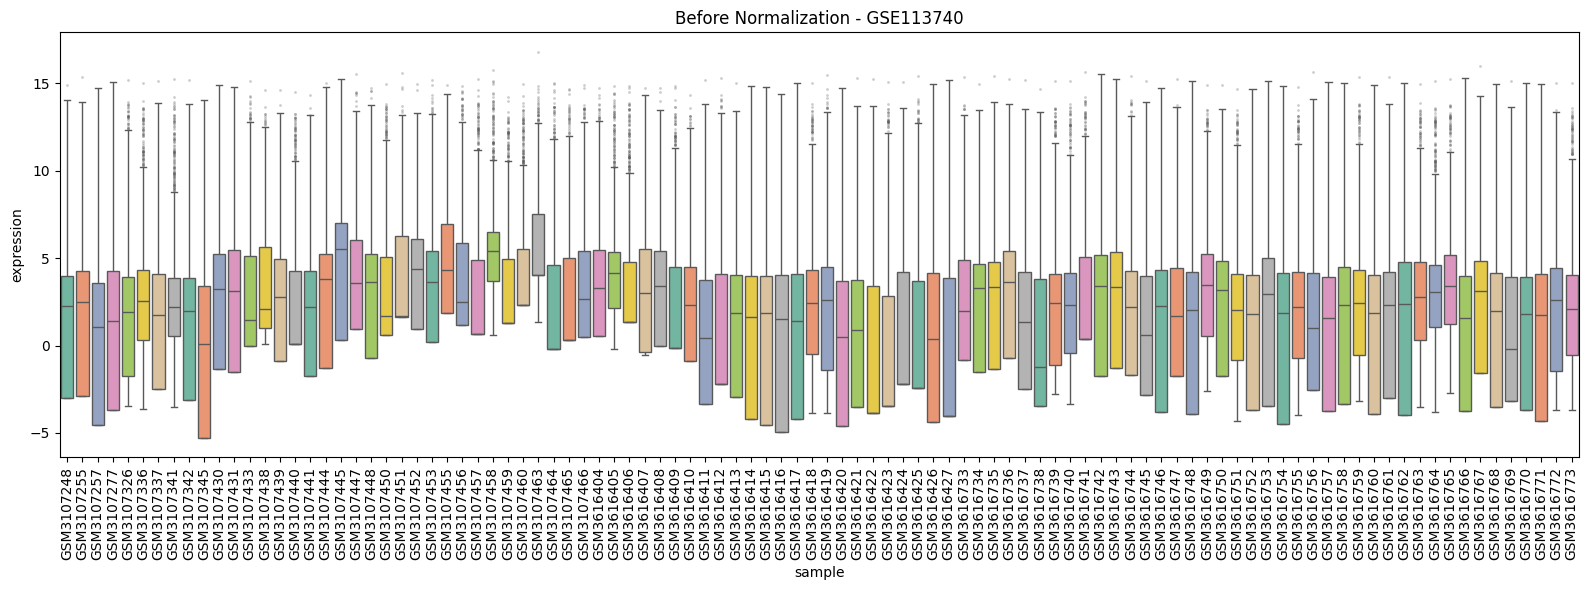

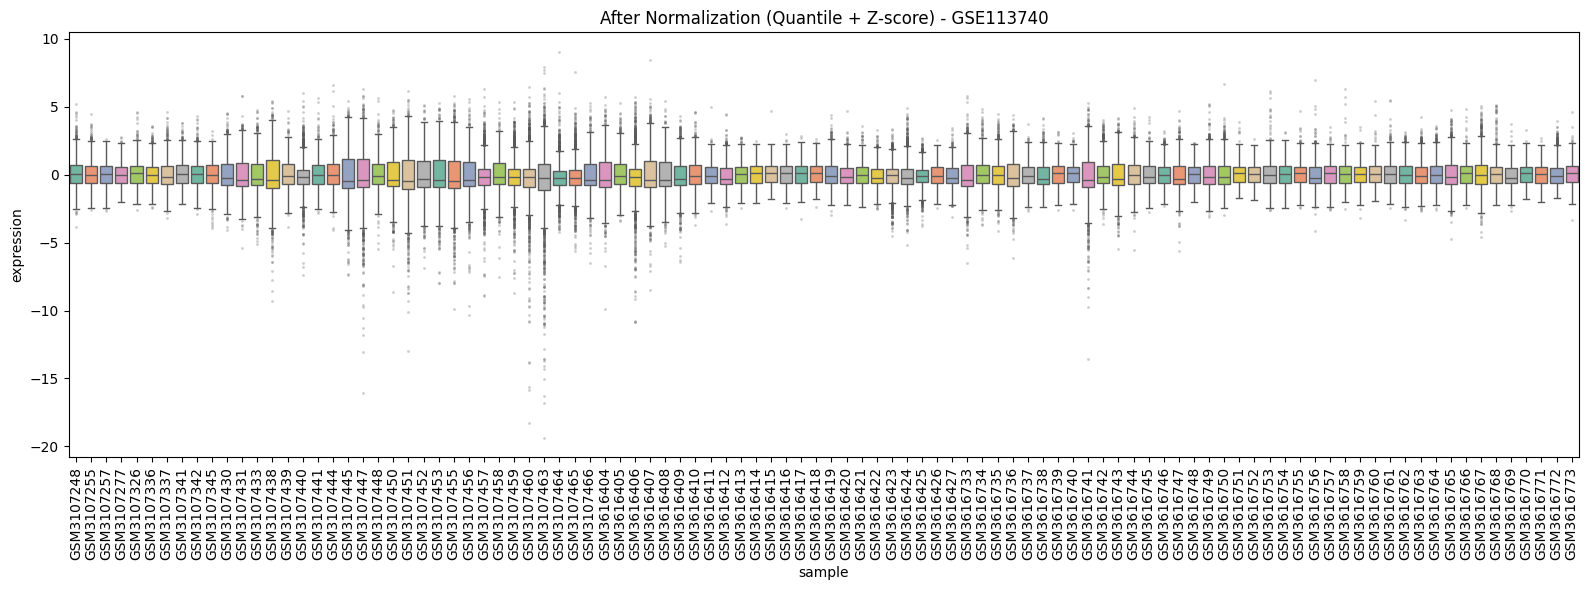

In [9]:
# Data preprocess of GSE113740
import GEOparse
import os
import pandas as pd
import warnings
import logging
from sklearn.preprocessing import quantile_transform, minmax_scale, StandardScaler, robust_scale
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=SyntaxWarning)
logging.getLogger("GEOparse").setLevel(logging.CRITICAL)
GEO_ID = "GSE113740"
base_path = "D:/MSc Genetic/Master thesis/coding/GEO_Data/"
filepath = os.path.join(base_path, f"{GEO_ID}_family.soft.gz")

if not os.path.exists(filepath):
    raise FileNotFoundError(f"File not found: {filepath}")
gse = GEOparse.get_GEO(filepath=filepath)

# 1. Xử lý Phenotype
pheno_data = pd.DataFrame([gsm.metadata for gsm in gse.gsms.values()])
pheno_data.to_excel ("GSE113740.xlsx", index=True)
# Xử lý list trong metadata
pheno_data["title"] = pheno_data["title"].apply(lambda x: x[0] if isinstance(x, list) else x)
pheno_data["geo_accession"] = pheno_data["geo_accession"].apply(lambda x: x[0] if isinstance(x, list) else x)
# Hàm dán nhãn theo yêu cầu cụ thể của bạn
def label_logic(title):
    # Kiểm tra nhóm No cancer (dựa trên từ khóa Non-cancer)
    if "Non-cancer" in title: return "No cancer"
    # Kiểm tra nhóm CRC (dựa trên Colorectal Cancer hoặc mã CC)
    elif "Colorectal Cancer" in title or "[CC" in title: return "CRC"
    return "Other"

# Áp dụng dán nhãn
pheno_data["type"] = pheno_data["title"].apply(label_logic)
# Lọc chỉ lấy 2 nhóm quan trọng
pheno_data_filtered = pheno_data[pheno_data["type"].isin(["No cancer", "CRC"])].copy()
pheno_data_filtered.set_index("geo_accession", inplace=True)

# Thống kê sau khi dán nhãn
print(f"Phenotype Summary for {GEO_ID}")
disease_counts = pheno_data_filtered["type"].value_counts()
print(pd.DataFrame({"Count": disease_counts, "Percentage (%)": (disease_counts / disease_counts.sum() * 100).round(2)}))
print("-------------------------------------------------------")
# Cập nhật mục tiêu cho GSE113740
target_diseases = ["No cancer", "CRC"]
label_map = {"No cancer": 0, "CRC": 1}

#2. Trích xuất Expression Data (Sửa lỗi ID_REF nếu có)
try:
    expression_data = gse.pivot_samples('VALUE').T
except:
    expression_data = gse.pivot_samples(values='VALUE', index='ID').T

expression_data.index.name = None
# Xử lý các probe trùng lặp bằng cách lấy giá trị trung bình (Mean)
expression_data = expression_data.groupby(level=0, axis=1).mean().dropna(axis=1, how='any')
# Đồng bộ lọc loại mẫu giữa Phenotype và Expression
expression_data = expression_data.loc[expression_data.index.isin(pheno_data_filtered.index)]
pheno_data_filtered = pheno_data_filtered.loc[expression_data.index]

print(f"-> Ma trận biểu hiện thô: {expression_data.shape[0]} mẫu | {expression_data.shape[1]} đặc trưng đầu vào.")

# ------------------------------------------------------------------------------------------------------------------------
#3. Normalization với limma (rpy2)
from rpy2.robjects import pandas2ri, r, globalenv
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
import pandas as pd

# 3.1: Chuẩn bị dữ liệu cho R
# ĐẢM BẢO Chỉ chuyển ma trận biểu hiện thuần túy (Không chèn cột type_numeric dư thừa)
expression_df_t = expression_data.T  # Các mẫu phải nằm ở cột để Limma đọc chuẩn

# 3.2: Chuyển sang R
with localconverter(default_converter + pandas2ri.converter):
    expr_r = pandas2ri.py2rpy(expression_df_t)
# 3.3: Load thư viện limma và chuẩn hóa
r("library(limma)")
globalenv["expr_r"] = expr_r
r("expr_norm <- normalizeBetweenArrays(expr_r, method='quantile')")
expr_norm_r = r("expr_norm")

# 3.4: Chuyển lại về Python
with localconverter(default_converter + pandas2ri.converter):
    normalized_mat = pandas2ri.rpy2py(expr_norm_r)
# Khôi phục cấu trúc DataFrame của Python sau khi chuẩn hóa xong
normalized_df = pd.DataFrame(normalized_mat, index=expression_data.columns, columns=expression_data.index).T

# --- ĐOẠN SỬA ĐỔI ĐỒNG BỘ CHO GSE113740 ---
# 4. THỰC HIỆN Z-SCORE ĐỂ ĐỒNG BỘ PHÂN PHỐI LÂM SÀNG
scaler = StandardScaler()
z_scored_mat = scaler.fit_transform(normalized_df)
normalized_z_df = pd.DataFrame(z_scored_mat, index=normalized_df.index, columns=normalized_df.columns)

# Gắn nhãn cấu trúc phân loại ML (0: Đối chứng, 1: Ung thư CRC)
label_map = {"No cancer": 0, "CRC": 1}
normalized_z_df["TYPE"] = pheno_data_filtered["type"].map(label_map)

# Đẩy cột TYPE lên đầu bảng dữ liệu đầu ra
cols = ['TYPE'] + [col for col in normalized_z_df.columns if col != 'TYPE']
normalized_z_df = normalized_z_df[cols]

# Xuất bảng dữ liệu chuẩn hóa cuối cùng phục vụ bước gộp External Validation
output_file_path = "D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/GSE113740_processed.txt"
normalized_z_df.to_csv(output_file_path, sep='\t', index=True)
print(f"-> [OK] GSE113740: Đã hoàn tất xử lý và lưu tại: {output_file_path}")

#5. Boxplot Normalisation Visualise (Đã sửa lỗi duplicate labels)
# Chỉ chọn 100 mẫu đầu để biểu đồ rõ ràng hơn
top_samples = expression_data.index[:100]

expression_long = expression_data.loc[top_samples].melt(ignore_index=False, var_name="miRNA", value_name="expression")
expression_long["sample"] = expression_long.index

normalized_long = normalized_z_df.loc[top_samples].drop(columns=["TYPE"]).melt(ignore_index=False, var_name="miRNA", value_name="expression")
normalized_long["sample"] = normalized_long.index

flier_props = dict(marker='o', markersize=1, linestyle='none', alpha=0.3, color='black')
# vẽ boxplot trước khi normalization
plt.figure(figsize=(16, 6))
sns.boxplot(x="sample", y="expression", palette="Set2", data=expression_long, flierprops=flier_props)
plt.title(f"Before Normalization - {GEO_ID}")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
# vẽ boxplot sau khi normalization
plt.figure(figsize=(16, 6))
sns.boxplot(x="sample", y="expression", palette="Set2", data=normalized_long, flierprops=flier_props)
plt.title(f"After Normalization (Quantile + Z-score) - {GEO_ID}")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [10]:
# Kiểm tra thu viện R
import rpy2.robjects as ro

# Kiểm tra danh sách các gói đã cài đặt trong R
def check_r_packages(packages):
    ro.r('installed_pkgs <- installed.packages()[,1]')
    for pkg in packages:
        is_installed = ro.r(f'"{pkg}" %in% installed_pkgs')[0]
        if is_installed:
            print(f"✅ Thư viện R '{pkg}': ĐÃ SẴN SÀNG.")
        else:
            print(f"❌ Thư viện R '{pkg}': CHƯA CÀI ĐẶT. Đang tiến hành cài đặt...")
            ro.r(f'if (!require("BiocManager", quietly = TRUE)) install.packages("BiocManager")')
            ro.r(f'BiocManager::install("{pkg}", update = FALSE, ask = FALSE)')

# Thực hiện kiểm tra
check_r_packages(["limma", "sva"])

✅ Thư viện R 'limma': ĐÃ SẴN SÀNG.
✅ Thư viện R 'sva': ĐÃ SẴN SÀNG.


In [11]:
! pip install scikit-learn
! pip install boruta
! pip install matplotlib-venn
! pip install xgboost matplotlib-venn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


--- BƯỚC 1: Đọc dữ liệu ---
-- tải và chuẩn hóa nhãn từng bộ dữ liệu -
-> GSE113486 đã load thành công: 140 mẫu, 2566 đặc trưng.
   Phân bố nhãn nhị phân: {0: 100, 1: 40}
-> GSE211692 đã load thành công: 7239 mẫu, 2566 đặc trưng.
   Phân bố nhãn nhị phân: {0: 5643, 1: 1596}
-> GSE106817 đã load thành công: 2874 mẫu, 2566 đặc trưng.
   Phân bố nhãn nhị phân: {0: 2759, 1: 115}

Số lượng miRNA chung thực tế tìm thấy: 1
5 miRNA đầu của GSE113486: ['type', 'mimat0000062', 'mimat0000063', 'mimat0000064', 'mimat0000065']
5 miRNA đầu của GSE211692: ['type', 'hsa-mir-28-3p', 'hsa-mir-27a-5p', 'hsa-mir-518b', 'hsa-mir-520b']
5 miRNA đầu của GSE106817: ['type', 'mimat0000062', 'mimat0000063', 'mimat0000064', 'mimat0000065']
--- Đang bắt đầu quá trình Mapping ID cho GSE211692 ---
-> Đã khớp được 2565 miRNA cho GSE211692.

--- BƯỚC 3: Đồng bộ định dạng chữ HOA và Tên cột nhãn ---
-> Số lượng đặc trưng miRNA chung giữa cả 3 tập sau chuẩn hóa: 2564
10 mã MIMAT đầu của df1 (GSE113486): ['MIMAT0000062'

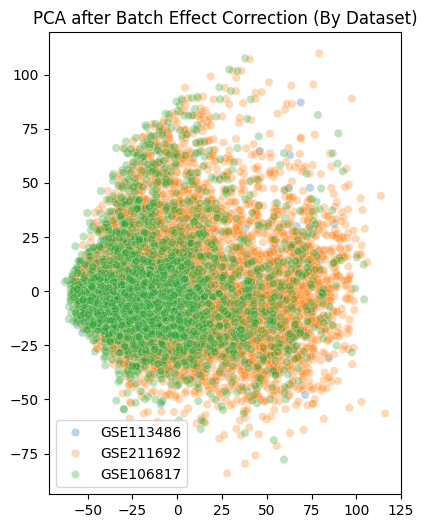

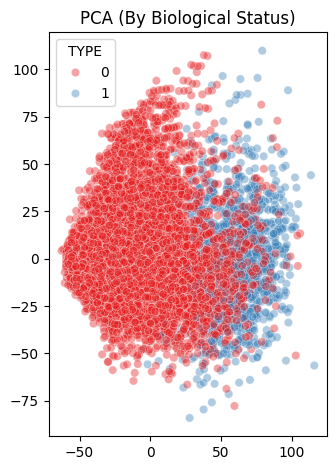

--- Đang chia tập dữ liệu 70:30 ---
[THÀNH CÔNG AN TOÀN] Đã xuất dữ liệu!
-> File Train_70.txt: (7177, 2565) (Cột nhãn chuẩn: 'TYPE')
-> File Test_30.txt:  (3076, 2565) (Cột nhãn chuẩn: 'TYPE')


In [12]:
#Gộp và xử lý Batch effect 3 tệp GSE113486, GSE106817, GSE211692 để chia tập 70:30
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import os
import numpy as np
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# Cấu hình môi trường
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")

# ==========================================
# 1. Đọc dữ liệu
# ==========================================
print("--- BƯỚC 1: Đọc dữ liệu ---")
def load_data_final(file_path, name):
    df = pd.read_csv(file_path, sep="\t", index_col=0)
    # 1. Chuyển tất cả tên cột về chữ thường và xóa khoảng trắng
    df.columns = [str(c).strip().lower() for c in df.columns]
    
    # 2. Tìm cột nhãn (chấp nhận cả 'type', 'group', 'status')
    label_cols = [c for c in df.columns if c in ['type', 'target', 'group', 'status', 'label']]
    if label_cols:
        # Đổi tên cột nhãn về 'type' để thống nhất
        df = df.rename(columns={label_cols[0]: 'type'})
        
        # Logic dán nhãn thông minh
        def fix_label(x):
            x_str = str(x).lower().strip()
            if any(k in x_str for k in ['cancer', 'crc', '1', '1.0']): 
                return 1
            if any(k in x_str for k in ['control', 'normal', 'no', '0', '0.0', 'non-cancer']): 
                return 0
            return np.nan
        df['type'] = df['type'].apply(fix_label)
    else:
        raise KeyError(f"Không tìm thấy cột nhãn nào trong file của {name}. Các cột đang có: {list(df.columns[:5])}")
    
    print(f"-> {name} đã load thành công: {df.shape[0]} mẫu, {df.shape[1]} đặc trưng.")
    print(f"   Phân bố nhãn nhị phân: {df['type'].value_counts().to_dict()}")
    return df

# 2. Tải dữ liệu (Thay GSE113740 bằng GSE113486 như bạn dự định)
print("-- tải và chuẩn hóa nhãn từng bộ dữ liệu -")

    # Bạn hãy đảm bảo file GSE113486 đã được lưu đúng tên này
df1 = load_data_final("GSE113486_ready_to_merge.txt", "GSE113486")
df2 = load_data_final("GSE211692_ready_to_merge.txt", "GSE211692")  # File thô cần đổi ID tên cột
df3 = load_data_final("GSE106817_ready_to_merge.txt", "GSE106817")

# KIỂM TRA ĐIỂM CHUNG TRƯỚC KHI GỘP
common_mirnas = set(df1.columns) & set(df2.columns) & set(df3.columns)
print(f"\nSố lượng miRNA chung thực tế tìm thấy: {len(common_mirnas)}")
print("5 miRNA đầu của GSE113486:", list(df1.columns[:5]))
print("5 miRNA đầu của GSE211692:", list(df2.columns[:5]))
print("5 miRNA đầu của GSE106817:", list(df3.columns[:5]))
#XỬ LÝ LABEL ĐỐI VỚI GSE211692
# 1. Đọc file platform để lấy bảng quy đổi
print("--- Đang bắt đầu quá trình Mapping ID cho GSE211692 ---")

# 1. Đọc file platform và chuẩn hóa mapping dictionary
# Chuyển tất cả về chữ thường để khớp tuyệt đối
platform = pd.read_csv("GSE211692_platform.txt", sep="\t")
def clean_name(name):
    # Chuyển về chữ thường, xóa dấu gạch ngang, gạch dưới và khoảng trắng
    return str(name).lower().replace('-', '').replace('_', '').strip()

# 2. Tạo Dictionary mapping với key đã được làm sạch
# { 'hsamir283p': 'MIMAT0000062', ... }
mapping_dict = {clean_name(k): v for k, v in zip(platform['miRNA_ID_LIST'], platform['ID'])}
# 3. Đổi tên cột cho df2 bằng cách làm sạch tên cột hiện tại rồi tra từ điển
new_cols = []
count_mapped = 0
for col in df2.columns:
    cleaned_col = clean_name(col)
    if cleaned_col == 'type':
        new_cols.append('type')
    elif cleaned_col in mapping_dict:
        new_cols.append(mapping_dict[cleaned_col])
        count_mapped += 1
    else:
        new_cols.append(col)

df2.columns = new_cols
print(f"-> Đã khớp được {count_mapped} miRNA cho GSE211692.")

# 4. Chuẩn hóa chữ hoa tên Gene & Thống nhất cột nhãn 'TYPE'
# ==========================================
print("\n--- BƯỚC 3: Đồng bộ định dạng chữ HOA và Tên cột nhãn ---")

def finalize_df_format(df):
    # Chuyển toàn bộ cột sang chữ HOA
    df.columns = [str(c).upper().strip() for c in df.columns]
    # Loại bỏ các cột trùng lặp nội bộ nếu có
    df = df.loc[:, ~df.columns.duplicated()]
    return df

df1_final = finalize_df_format(df1)
df2_final = finalize_df_format(df2)
df3_final = finalize_df_format(df3)
# Kiểm tra số lượng miRNA chung
common_mirnas = set(df1_final.columns) & set(df2_final.columns) & set(df3_final.columns)
common_mirnas = {m for m in common_mirnas if m != 'TYPE'}
print(f"-> Số lượng đặc trưng miRNA chung giữa cả 3 tập sau chuẩn hóa: {len(common_mirnas)}")

# kiểm tra mã mimat
print("10 mã MIMAT đầu của df1 (GSE113486):", sorted([c for c in df1.columns if c != 'type'])[:10])
print("10 mã MIMAT đầu của df2 (GSE211692):", sorted([c for c in df2.columns if c != 'type'])[:10])
# 6. Tiến hành gộp dữ liệu (Inner Join)
## Xử lý cột bị trùng: Khi chúng ta mapping hoặc chuẩn hóa chữ hoa/thường, có thể có hai cột khác nhau ban đầu nhưng sau khi đổi tên lại trở thành giống hệt nhau (ví dụ: mimat001 và MIMAT001 đều thành MIMAT001), khiến Pandas không thể gộp theo trục dọc
def final_clean_before_concat(df):
    # Loại bỏ các cột trùng tên trong nội bộ từng file (nếu có)
    df = df.loc[:, ~df.columns.duplicated()]
    return df

# Làm sạch cả 3 file trước khi gộp
df1_final = final_clean_before_concat(df1)
df2_final = final_clean_before_concat(df2)
df3_final = final_clean_before_concat(df3)
print("--- Đang gộp dữ liệu ---")
try:
    # Thực hiện gộp
    df_merged = pd.concat([df1_final, df2_final, df3_final], axis=0, join='inner')
    
    # Đảm bảo cột nhãn chuẩn tên 'TYPE' và không có NaN
    df_merged = df_merged.dropna(subset=['TYPE'])
    df_merged['TYPE'] = df_merged['TYPE'].astype(int)
    
    print(f"-> Gộp THÀNH CÔNG!")
    print(f"Tổng số mẫu: {df_merged.shape[0]}")
    print(f"Số lượng miRNA chung: {df_merged.shape[1] - 1}")
    print(f"Phân bố nhãn:\n{df_merged['TYPE'].value_counts()}")
except Exception as e:
    print(f"LỖI khi gộp: {e}")

# 7. CHẠY BATCH EFFECT (Limma) - Bước quyết định
print("--- Đang thực hiện Batch Effect Correction ---")

# Chuẩn bị ma trận: miRNA làm hàng (Rows), Mẫu làm cột (Columns)
# Loại bỏ cột TYPE trước khi chuyển sang R
X_to_r = df_merged.drop(columns=['TYPE']).T
# Đảm bảo dữ liệu là số và không có giá trị trống
X_to_r = X_to_r.fillna(0).apply(pd.to_numeric)

# Tạo danh sách batch tương ứng số mẫu: GSE113486(140), GSE211692(7239), GSE106817(2874)
batch_list = [1]*140 + [2]*7239 + [3]*2874 #tạo danh sách có 140 dòng số 1, 7239 số 2,....
group_list = df_merged['TYPE'].tolist() # Danh sách 0 và 1

with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['dat_mat'] = ro.conversion.py2rpy(X_to_r)
    ro.globalenv['batch_vec'] = ro.IntVector(batch_list)
    ro.globalenv['group_vec'] = ro.IntVector(group_list)

#Chạy Limma trong R với model.matrix
ro.r('''
    library(limma)
    dat <- as.matrix(dat_mat)
    mode(dat) <- "numeric"
    
    # Tạo design matrix để bảo vệ biến mục tiêu (Cancer/Normal)
    # R sẽ biết không được xóa các khác biệt thuộc về nhóm TYPE
    design <- model.matrix(~as.factor(group_vec))
    
    # Khử nhiễu Batch Effect
    dat_corrected <- removeBatchEffect(dat, batch=as.factor(batch_vec), design=design)
    
    result_df <- as.data.frame(t(dat_corrected))
''')
#Lấy kết quả về Python
with localconverter(ro.default_converter + pandas2ri.converter):
    X_corrected = ro.conversion.rpy2py(ro.r('result_df'))

X_corrected.index = df_merged.index
df_final = pd.concat([df_merged['TYPE'], X_corrected], axis=1)

print("-> Hoàn tất Batch Effect Correction!")
print(f"Kích thước dữ liệu cuối cùng: {df_final.shape}")
# kiểm tra lần nữa để chắn chắn đã xử lý nhiễu thành công
df_final.isnull().sum().sum() #Kết quả phải bằng 0 (không còn giá trị rỗng).

df_final['TYPE'].value_counts() #So sánh lại với tổng số mẫu ban đầu để đảm bảo không mất mẫu nào trong quá trình chạy R.
# một cách trực quan nhất để khẳng định code đã "xử lý nhiễu" thành công là vẽ biểu đồ PCA (Principal Component Analysis)
# 8. Trực quan hóa PCA & Chia dữ liệu 70:30
print("\n--- BƯỚC 6: Trực quan hóa PCA và xuất tập Train/Test ---")
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
pca = PCA(n_components=2)
components = pca.fit_transform(df_final.drop(columns=['TYPE']))

plt.figure(figsize=(10, 6))
# Vẽ theo Batch để xem các bộ dữ liệu đã hòa trộn chưa
plt.subplot(1, 2, 1)
batch_labels = ['GSE113486']*len(df1_final) + ['GSE211692']*len(df2_final) + ['GSE106817']*len(df3_final)
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=batch_labels, alpha=0.3)
plt.title("PCA after Batch Effect Correction (By Dataset)")
plt.show()
# Biểu đồ 2: Xem theo Nhãn bệnh (Cancer vs Normal)
plt.subplot(1, 2, 2)
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=df_final['TYPE'], palette='Set1', alpha=0.4)
plt.title("PCA theo Nhãn TYPE (Kiểm tra phân tách sinh học)")
plt.title("PCA (By Biological Status)")
plt.tight_layout()
plt.show()

# --- 9: CHIA DỮ LIỆU 70:30 VÀ LƯU FILE ---
print("--- Đang chia tập dữ liệu 70:30 ---")
train_df, test_df = train_test_split(
    df_final, 
    test_size=0.3, 
    random_state=42, 
    stratify=df_final['TYPE']
)

# Lưu lại để làm Feature Selection ở cell sau
train_df.to_csv("Train_70.txt", sep="\t")
test_df.to_csv("Test_30.txt", sep="\t")

print(f"[THÀNH CÔNG AN TOÀN] Đã xuất dữ liệu!")
print(f"-> File Train_70.txt: {train_df.shape} (Cột nhãn chuẩn: 'TYPE')")
print(f"-> File Test_30.txt:  {test_df.shape} (Cột nhãn chuẩn: 'TYPE')")

--- Thực hiện DEG (FDR < 0.05, |Log2FC| >= 1) ---
--- BƯỚC 1: Chuẩn bị dữ liệu huấn luyện ---
-> Đã bóc tách thành công cột nhãn 'TYPE'
-> Số lượng mẫu: 7177 | Số lượng đặc trưng: 2564
-> Đang tính toán thống kê bằng Limma (R)...

--- BƯỚC 2: Lọc miRNA tiềm năng ---
Kết quả lọc:
- Số miRNA tăng (Up-regulated): 480
- Số miRNA giảm (Down-regulated): 621
- TỔNG CỘNG: 1101 miRNA biểu hiện khác biệt.

TOP 10 miRNA TĂNG MẠNH NHẤT (UP-REGULATED):
                 logFC  adj.P.Val
MIMAT0005898  6.293071        0.0
MIMAT0000440  4.631871        0.0
MIMAT0001631  4.010833        0.0
MIMAT0024615  3.991247        0.0
MIMAT0000101  3.420095        0.0
MIMAT0000104  3.338260        0.0
MIMAT0000425  3.283956        0.0
MIMAT0000071  3.181891        0.0
MIMAT0000077  3.128985        0.0
MIMAT0019218  3.093100        0.0

TOP 10 miRNA GIẢM MẠNH NHẤT (DOWN-REGULATED):
                 logFC  adj.P.Val
MIMAT0019710 -4.983125        0.0
MIMAT0004602 -4.775878        0.0
MIMAT0027614 -4.769220        0.0

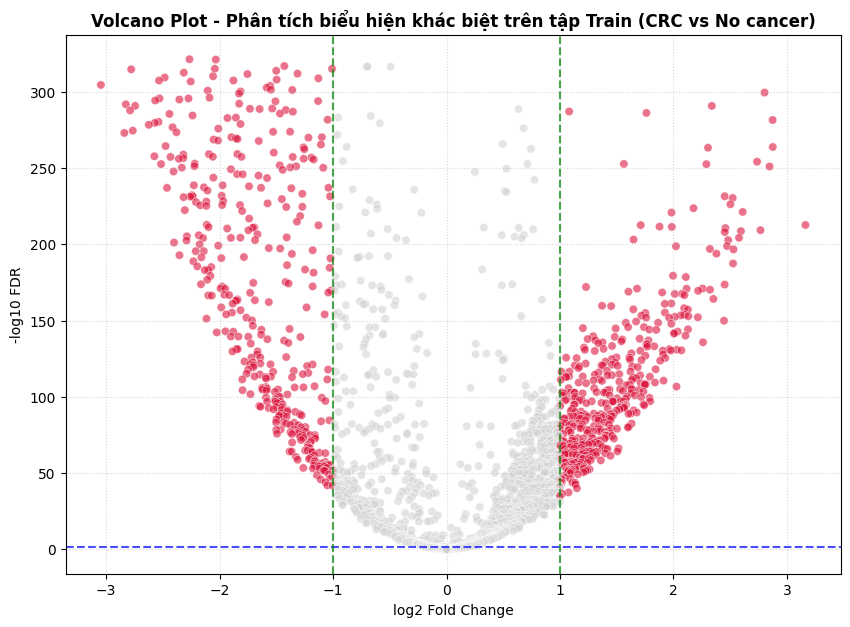

In [13]:
# Chạy DEG (Lọc thô các miRNA có ý nghĩa)
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import os
import numpy as np
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# Cấu hình môi trường
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")

print("--- Thực hiện DEG (FDR < 0.05, |Log2FC| >= 1) ---")

# 1. Chuẩn bị dữ liệu từ tập Train_70
# ==========================================
print("--- BƯỚC 1: Chuẩn bị dữ liệu huấn luyện ---")
# Đảm bảo train_df đã có sẵn từ cell trước
# Lưu ý: Cột nhãn của bạn đang là 'TYPE' (viết hoa)
# Đọc lại dữ liệu từ file đã lưu sau khi Restart Kernel
train_df = pd.read_csv("Train_70.txt", sep="\t", index_col=0)
# Tách cột nhãn 'target' và ánh xạ sang dạng số (CRC -> 1, No cancer -> 0) để Limma xử lý dễ dàng
# Dò tìm cột nhãn tự động không phân biệt hoa thường
label_col = [c for c in train_df.columns if c.upper() in ['TARGET', 'TYPE']][0]
labels_raw = train_df[label_col].values
# Ánh xạ nhãn sang dạng số (chấp nhận cả chuỗi chữ hoa/thường hoặc số dạng chuỗi)
label_vec = np.where((labels_raw == 'CRC') | (labels_raw == '1') | (labels_raw == 1), 1, 0)

# Loại bỏ các cột lâm sàng/hệ thống để giữ lại ma trận biểu hiện miRNA
# errors='ignore' giúp bỏ qua nếu cột đó không tồn tại trong file
expr = train_df.drop(columns=['target', 'TARGET', 'type', 'TYPE', 'batch', 'BATCH'], errors='ignore').T

print(f"-> Đã bóc tách thành công cột nhãn '{label_col}'")
print(f"-> Số lượng mẫu: {expr.shape[1]} | Số lượng đặc trưng: {expr.shape[0]}")

# 2. Chạy thuật toán Limma qua R
# ==========================================
def run_limma_train(expr_df, label_vec):
    print("-> Đang tính toán thống kê bằng Limma (R)...")
    
    with localconverter(ro.default_converter + pandas2ri.converter):
        expr_r = ro.conversion.py2rpy(expr_df)

    ro.r('library(limma)')
    ro.globalenv['group'] = ro.IntVector(label_vec)
    ro.globalenv['expr_r'] = expr_r

    ro.r('''
        group <- factor(group)
        # Thiết kế ma trận so sánh: group1 (Cancer) vs group0 (Normal)
        design <- model.matrix(~ 0 + group)
        colnames(design) <- c("group0", "group1")
        
        fit <- lmFit(expr_r, design)
        contrast.matrix <- makeContrasts(group1 - group0, levels=design)
        fit2 <- contrasts.fit(fit, contrast.matrix)
        fit2 <- eBayes(fit2)
        
        # Lấy toàn bộ kết quả, hiệu chỉnh P-value bằng phương pháp FDR (BH)
        res <- topTable(fit2, number=Inf, adjust="fdr")
    ''')

    with localconverter(ro.default_converter + pandas2ri.converter):
        result_df = ro.conversion.rpy2py(ro.r('res'))
    
    return result_df

# Thực thi Limma
res_limma = run_limma_train(expr, label_vec)

# 3. Lọc miRNA theo ngưỡng: FDR < 0.05 và |logFC| >= 1
# ==========================================
print("\n--- BƯỚC 2: Lọc miRNA tiềm năng ---")

# FDR trong Limma chính là cột 'adj.P.Val'
deg_sig = res_limma[(res_limma['adj.P.Val'] < 0.05) & (abs(res_limma['logFC']) >= 1)]

# Phân loại Up và Down
up_mirnas = deg_sig[deg_sig['logFC'] >= 1].index.tolist()
down_mirnas = deg_sig[deg_sig['logFC'] <= -1].index.tolist()
combined_sig_list = deg_sig.index.tolist()

print(f"Kết quả lọc:")
print(f"- Số miRNA tăng (Up-regulated): {len(up_mirnas)}")
print(f"- Số miRNA giảm (Down-regulated): {len(down_mirnas)}")
print(f"- TỔNG CỘNG: {len(combined_sig_list)} miRNA biểu hiện khác biệt.")
# Sắp xếp theo ý nghĩa thống kê (FDR thấp nhất) và độ biến đổi (logFC cao nhất)
top_up = deg_sig[deg_sig['logFC'] >= 1].sort_values(by=['adj.P.Val', 'logFC'], ascending=[True, False]).head(10)
top_down = deg_sig[deg_sig['logFC'] <= -1].sort_values(by=['adj.P.Val', 'logFC'], ascending=[True, True]).head(10)

print("\n" + "="*30)
print("TOP 10 miRNA TĂNG MẠNH NHẤT (UP-REGULATED):")
print(top_up[['logFC', 'adj.P.Val']])

print("\n" + "="*30)
print("TOP 10 miRNA GIẢM MẠNH NHẤT (DOWN-REGULATED):")
print(top_down[['logFC', 'adj.P.Val']])
print("="*30)

# Lưu danh sách miRNA có ý nghĩa phục vụ các bước Feature Selection sau (Lasso, Boruta...) ở cell sau
pd.DataFrame({'miRNA': combined_sig_list}).to_csv("DEG_results_list.csv", index=False)
#Lưu TOÀN BỘ kết quả Limma (tất cả miRNA, cả có ý nghĩa và không)
res_limma.to_csv("DEG_Full_Table_All_miRNAs.csv", index=True)
#Lưu danh sách miRNA CÓ Ý NGHĨA kèm số liệu (P-value < 0.05, |logFC| >= 1)
# Chúng ta dùng biến deg_sig đã lọc ở trên
deg_sig.to_csv("DEG_Significant_Results_Full_Stats.csv", index=True)
# 4. Trực quan hóa (Volcano Plot) cho tập Train
# ==========================================
plt.figure(figsize=(10, 7))
sns.scatterplot(data=res_limma, x='logFC', y=-np.log10(res_limma['adj.P.Val']), 
                hue=(abs(res_limma['logFC']) >= 1) & (res_limma['adj.P.Val'] < 0.05),
                palette={True: 'crimson', False: 'lightgrey'}, alpha=0.6, legend=False)
plt.axhline(-np.log10(0.05), color='blue', linestyle='--', alpha=0.7, label='FDR = 0.05')
plt.axvline(1, color='green', linestyle='--', alpha=0.7, label='log2FC = 1')
plt.axvline(-1, color='green', linestyle='--', alpha=0.7)
plt.title("Volcano Plot - Phân tích biểu hiện khác biệt trên tập Train (CRC vs No cancer)", fontsize=12, fontweight='bold')
plt.xlabel("log2 Fold Change", fontsize=10)
plt.ylabel("-log10 FDR", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

In [14]:
# BƯỚC CHUẨN HÓA Z-SCORE (SAU DE VÀ CHIA TẬP 70:30)
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import os
import numpy as np
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# Cấu hình môi trường
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")

print("--- Thực hiện chuẩn hóa Z-score tránh rò rỉ dữ liệu (Data Leakage) ---")

# 1. Đọc lại các tập dữ liệu thô (sau phân chia)
train_raw = pd.read_csv("Train_70.txt", sep="\t", index_col=0)
test_raw = pd.read_csv("Test_30.txt", sep="\t", index_col=0)

# Tách phần thông tin lâm sàng/nhãn ra trước khi chuẩn hóa giá trị biểu 
label_cols = [c for c in train_raw.columns if c.upper() in ['TARGET', 'TYPE']]
if len(label_cols) == 0:
    raise KeyError("Không tìm thấy cột nhãn 'TARGET' hoặc 'TYPE' trong dữ liệu!")
label_col = label_cols[0]

# Tìm cột batch (nếu có, không bắt buộc)
batch_cols = [c for c in train_raw.columns if c.upper() in ['BATCH']]
batch_col = batch_cols[0] if len(batch_cols) > 0 else None
# Tạo danh sách các cột meta lâm sàng thực tế đang có
meta_cols = [label_col]
if batch_col:
    meta_cols.append(batch_col)
    print(f"-> Phát hiện cột nhãn: '{label_col}' và cột batch: '{batch_col}'")
else:
    print(f"-> Phát hiện cột nhãn: '{label_col}' (Không có cột batch)")
# Tách ma trận thông tin lâm sàng và ma trận biểu hiện biểu gen
train_meta = train_raw[meta_cols]
test_meta = test_raw[meta_cols]

train_expr_raw = train_raw.drop(columns=meta_cols)
test_expr_raw = test_raw.drop(columns=meta_cols)
# 2. Tính toán thông số trung bình (Mean) và độ lệch chuẩn (Std) TRÊN TẬP TRAIN
train_mean = train_expr_raw.mean(axis=0)
train_std = train_expr_raw.std(axis=0)

# Xử lý trường hợp độ lệch chuẩn = 0 (nếu có) để tránh lỗi chia cho 0 (Zero Division)
train_std[train_std == 0] = 1.0

# 3. Tiến hành áp dụng Z-score chuẩn hóa
# Sử dụng chính thông số của Train để áp dụng cho cả Train và Test
train_expr_scaled = (train_expr_raw - train_mean) / train_std
test_expr_scaled = (test_expr_raw - train_mean) / train_std

# 4. Gộp nhãn lại với ma trận biểu hiện đã được chuẩn hóa
train_scaled_final = pd.concat([train_meta, train_expr_scaled], axis=1)
test_scaled_final = pd.concat([test_meta, test_expr_scaled], axis=1)

# 5. Lưu lại dữ liệu đã chuẩn hóa phục vụ cho các thuật toán Machine Learning phía sau
train_scaled_final.to_csv("Train_70_Zscore.txt", sep="\t", index=True)
test_scaled_final.to_csv("Test_30_Zscore.txt", sep="\t", index=True)

# Lưu lại file parameters để sau này dùng cho tập External Validation (GSE độc lập)
pd.DataFrame({'mean': train_mean, 'std': train_std}).to_csv("Zscore_train_parameters.csv", index=True)

print(f"-> Hoàn thành chuẩn hóa Z-score thành công!")
print(f"- Kích thước tập Train đã chuẩn hóa: {train_scaled_final.shape}")
print(f"- Kích thước tập Test đã chuẩn hóa: {test_scaled_final.shape}")
print("-> Đã lưu dữ liệu chuẩn hóa vào file 'Train_70_Zscore.txt' và 'Test_30_Zscore.txt'.")

--- Thực hiện chuẩn hóa Z-score tránh rò rỉ dữ liệu (Data Leakage) ---
-> Phát hiện cột nhãn: 'TYPE' (Không có cột batch)
-> Hoàn thành chuẩn hóa Z-score thành công!
- Kích thước tập Train đã chuẩn hóa: (7177, 2565)
- Kích thước tập Test đã chuẩn hóa: (3076, 2565)
-> Đã lưu dữ liệu chuẩn hóa vào file 'Train_70_Zscore.txt' và 'Test_30_Zscore.txt'.


In [15]:
# Feature Selection (Lọc tinh) LASSO-BORUTA
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import os
import numpy as np
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LassoCV
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
# Cấu hình môi trường
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")

# 1. Đọc dữ liệu đã ĐƯỢC CHUẨN HÓA Z-SCORE
train_df = pd.read_csv("Train_70_Zscore.txt", sep="\t", index_col=0)

# Đọc lại danh sách miRNA từ bước DEG làm đầu vào lọc tinh
sig_mirna_list = pd.read_csv("DEG_results_list.csv")['miRNA'].tolist()
print(f"-> Sẵn sàng chạy Feature Selection với {len(sig_mirna_list)} miRNA đầu vào từ DEG.")

# 2. Chuẩn bị ma trận đặc trưng X và vector nhãn y (chuyển sang dạng số 0/1)
X_train_sig = train_df[sig_mirna_list]
labels_raw = train_df['TYPE'].values
y_train = np.where((labels_raw == 'CRC') | (labels_raw == '1') | (labels_raw == 1), 1, 0)

print(f"-> Kích thước ma trận đầu vào mô hình: {X_train_sig.shape}")

# --- THUẬT TOÁN 1: LASSO ---
print("--- Đang chạy LASSO để lọc đặc trưng ---")
# LassoCV tự động tìm hệ số alpha tối ưu nhất
lasso = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_train_sig, y_train)
lasso_features = X_train_sig.columns[lasso.coef_ != 0].tolist()
# XUẤT FILE 1
pd.DataFrame({'miRNA': lasso_features}).to_csv("Lasso_Selected_miRNAs.csv", index=False)
print(f"-> LASSO chọn: {len(lasso_features)} miRNA.")

# --- THUẬT TOÁN 2: BORUTA ---
print("\n--- Đang chạy Boruta (Thuật toán 'All-Relevant') ---")
# Dùng Random Forest làm nền tảng cho Boruta
rf = RandomForestClassifier(n_jobs=-1, max_depth=5, random_state=42)
# Khởi tạo Boruta
boruta_selector = BorutaPy(rf, n_estimators='auto', verbose=0, random_state=42)
boruta_selector.fit(X_train_sig.values, y_train)
# Lấy các đặc trưng mà Boruta xác nhận là quan trọng
boruta_features = X_train_sig.columns[boruta_selector.support_].tolist()
# XUẤT FILE 2
pd.DataFrame({'miRNA': boruta_features}).to_csv("Boruta_Selected_miRNAs.csv", index=False)
print(f"-> Boruta chọn: {len(boruta_features)} miRNA.")

# --- KẾT QUẢ GIAO THOA (FINAL SIGNATURE) ---
final_signature = list(set(lasso_features) & set(boruta_features))
print(f"\n=> CHỮ KÝ miRNA GIAO THOA (Lasso & Boruta): {len(final_signature)} miRNA.")
print(f"Danh sách: {final_signature}")
pd.DataFrame({'miRNA': final_signature}).to_csv("Final_Intersection_Selected_miRNAs.csv", index=False)

-> Sẵn sàng chạy Feature Selection với 1101 miRNA đầu vào từ DEG.
-> Kích thước ma trận đầu vào mô hình: (7177, 1101)
--- Đang chạy LASSO để lọc đặc trưng ---
-> LASSO chọn: 362 miRNA.

--- Đang chạy Boruta (Thuật toán 'All-Relevant') ---
-> Boruta chọn: 484 miRNA.

=> CHỮ KÝ miRNA GIAO THOA (Lasso & Boruta): 191 miRNA.
Danh sách: ['MIMAT0018360', 'MIMAT0022259', 'MIMAT0019957', 'MIMAT0019716', 'MIMAT0010497', 'MIMAT0023698', 'MIMAT0007347', 'MIMAT0019703', 'MIMAT0027430', 'MIMAT0019043', 'MIMAT0016890', 'MIMAT0017352', 'MIMAT0027614', 'MIMAT0018189', 'MIMAT0027521', 'MIMAT0018951', 'MIMAT0028125', 'MIMAT0015041', 'MIMAT0019925', 'MIMAT0017997', 'MIMAT0018947', 'MIMAT0022491', 'MIMAT0010367', 'MIMAT0005582', 'MIMAT0015008', 'MIMAT0019076', 'MIMAT0019710', 'MIMAT0004748', 'MIMAT0027671', 'MIMAT0003260', 'MIMAT0019692', 'MIMAT0019702', 'MIMAT0005866', 'MIMAT0019067', 'MIMAT0022497', 'MIMAT0003165', 'MIMAT0019884', 'MIMAT0019065', 'MIMAT0027586', 'MIMAT0030986', 'MIMAT0027619', 'MIMAT0019

--- Đang huấn luyện XGBoost trên 484 miRNA của Boruta ---


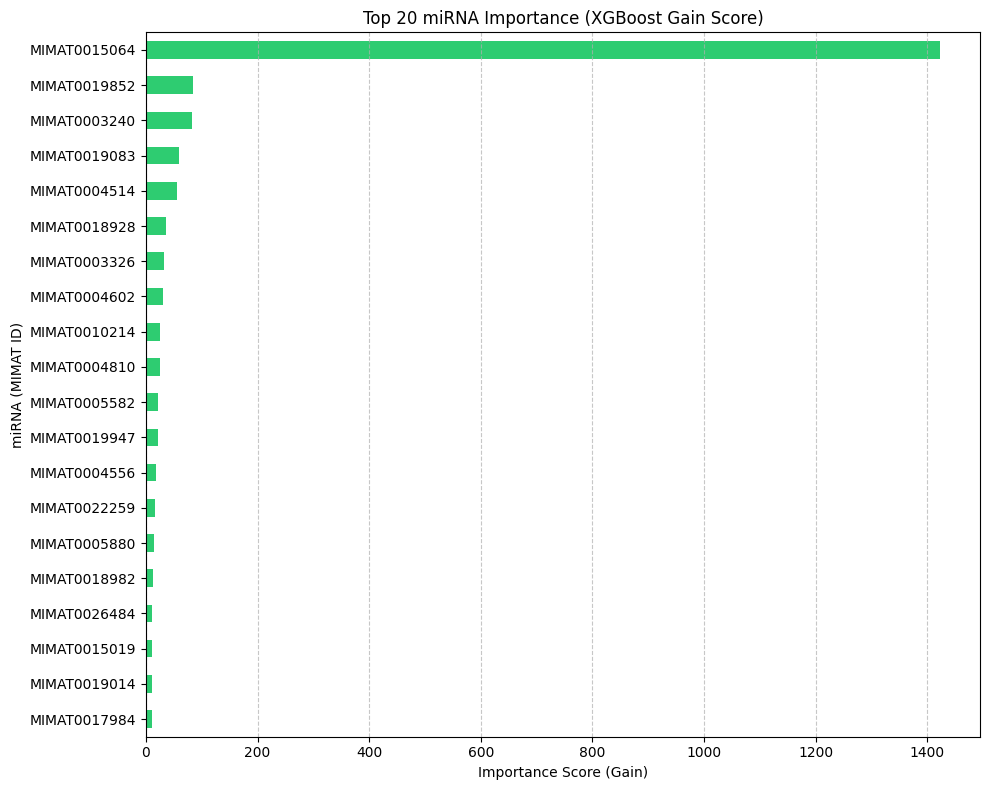

In [16]:
# Code chạy XGBoost cho kết quả của Boruta
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import os
import numpy as np
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LassoCV
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import plot_importance

# 1. Đọc lại dữ liệu Z-score và danh sách Boruta chọn
train_df = pd.read_csv("Train_70_Zscore.txt", sep="\t", index_col=0)
boruta_features = pd.read_csv("Boruta_Selected_miRNAs.csv")['miRNA'].tolist()

X_train_boruta = train_df[boruta_features]
labels_raw = train_df['TYPE'].values
y_train = np.where((labels_raw == 'CRC') | (labels_raw == '1') | (labels_raw == 1), 1, 0)

# 2. Khởi tạo và huấn luyện XGBoost
print("--- Đang huấn luyện XGBoost trên 484 miRNA của Boruta ---")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_boruta, y_train)

# 3. Vẽ biểu đồ Top 20 miRNA quan trọng nhất theo XGBoost
plt.figure(figsize=(10, 8))
# Lấy độ quan trọng (gain)
importance_types = ['gain']
for imp_type in importance_types:
    feat_importances = pd.Series(xgb_model.get_booster().get_score(importance_type=imp_type))
    feat_importances.nlargest(20).sort_values(ascending=True).plot(kind='barh', color='#2ecc71')

plt.title("Top 20 miRNA Importance (XGBoost Gain Score)")
plt.xlabel("Importance Score (Gain)")
plt.ylabel("miRNA (MIMAT ID)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("XGBoost_Importance_Top20.png", dpi=300)
plt.show()

# 4. Xuất file điểm quan trọng để bạn tra cứu
feat_importances.sort_values(ascending=False).to_csv("XGBoost_Feature_Importance.csv")

--- BƯỚC: Vẽ biểu đồ Venn và xuất danh sách giao thoa LASSO & Boruta ---
-> Thành công! Đã nạp 362 miRNA từ LASSO và 484 miRNA từ Boruta.
=> Số lượng miRNA giao thoa thực tế giữa Lasso & Boruta: 191
-> Đã lưu danh sách giao thoa vào file 'Lasso_Boruta_Common.csv'


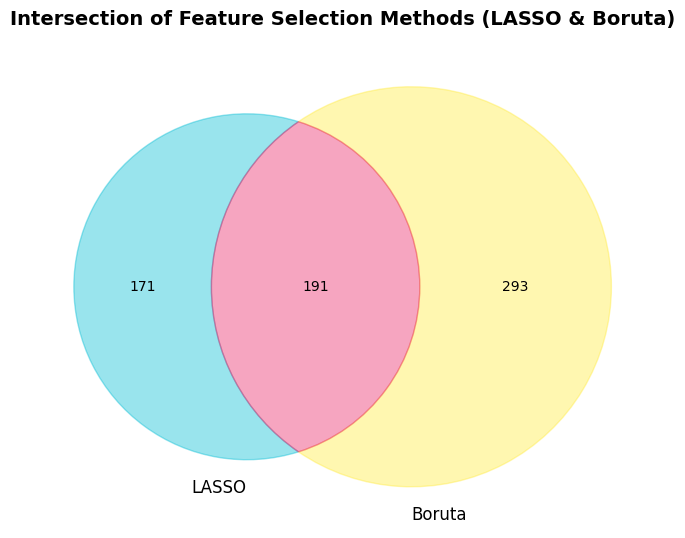

In [17]:
# Lấy danh sách tên các miRNA (MIMAT) mà Boruta và Lasso đã chọn
import pandas as pd
import os
import numpy as np
import random
import warnings
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Cấu hình môi trường
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")

print("--- BƯỚC: Vẽ biểu đồ Venn và xuất danh sách giao thoa LASSO & Boruta ---")

# Nạp an toàn dữ liệu từ ổ cứng (Tránh lỗi mất bộ nhớ RAM khi tắt máy)
try:
    lasso_list = pd.read_csv("Lasso_Selected_miRNAs.csv")['miRNA'].tolist()
    boruta_features = pd.read_csv("Boruta_Selected_miRNAs.csv")['miRNA'].tolist()
    print(f"-> Thành công! Đã nạp {len(lasso_list)} miRNA từ LASSO và {len(boruta_features)} miRNA từ Boruta.")
except Exception as e:
    print(f"Lỗi khi nạp file: {e}. Hãy đảm bảo các file .csv đã được lưu ở cell trước.")

# Tìm danh sách giao thoa (Intersection) giữa 2 thuật toán
common_lb = list(set(lasso_list) & set(boruta_features))
print(f"=> Số lượng miRNA giao thoa thực tế giữa Lasso & Boruta: {len(common_lb)}")

# Xuất danh sách giao thoa lưu trữ trực tiếp vào ổ cứng
pd.DataFrame({'miRNA': common_lb}).to_csv("Lasso_Boruta_Common.csv", index=False)
print("-> Đã lưu danh sách giao thoa vào file 'Lasso_Boruta_Common.csv'")

# Vẽ Venn Diagram (Lasso & Boruta)
plt.figure(figsize=(8, 8))
v = venn2([set(lasso_list), set(boruta_features)], set_labels=('LASSO', 'Boruta'))

# Chỉnh màu sắc đồ họa chuyên nghiệp phục vụ báo cáo thầy Nam
if v.get_patch_by_id('10'): v.get_patch_by_id('10').set_color('#00BCD4') # Chỉ Lasso
if v.get_patch_by_id('01'): v.get_patch_by_id('01').set_color('#FFEB3B') # Chỉ Boruta
if v.get_patch_by_id('11'): v.get_patch_by_id('11').set_color('#E91E63') # Giao thoa 2 bên

plt.title("Intersection of Feature Selection Methods (LASSO & Boruta)", fontsize=14, fontweight='bold', pad=15)
plt.savefig("Venn_Lasso_Boruta.png", dpi=300, bbox_inches='tight')
plt.show()

-> Đang bắt đầu chạy RFE dựa trên 1101 miRNA nền tảng từ bước DEG...
-> Thuật toán RFE đã chọn xong: 20 miRNA tốt nhất.

=> ĐÃ TÌM THẤY CHỮ KÝ ĐỒNG THUẬN: 11 miRNA TIỀM NĂNG NHẤT.
Danh sách các miRNA đồng thuận: ['MIMAT0018982', 'MIMAT0005582', 'MIMAT0022259', 'MIMAT0019852', 'MIMAT0005866', 'MIMAT0005951', 'MIMAT0003326', 'MIMAT0003240', 'MIMAT0019071', 'MIMAT0027430', 'MIMAT0019947']

--- BẢNG CHI TIẾT CHỮ KÝ miRNA ĐỒNG THUẬN KÈM CHỈ SỐ LÂM SÀNG ---
                 logFC      adj.P.Val
miRNA_ID                             
MIMAT0018982  2.610757  6.026813e-222
MIMAT0005582 -1.220548   0.000000e+00
MIMAT0022259  2.611002   0.000000e+00
MIMAT0019852 -3.478158   0.000000e+00
MIMAT0005866 -3.437423   0.000000e+00
MIMAT0005951  1.859896   0.000000e+00
MIMAT0003326  1.670439   0.000000e+00
MIMAT0003240 -3.631334   0.000000e+00
MIMAT0019071  2.078450   0.000000e+00
MIMAT0027430 -1.035917   0.000000e+00
MIMAT0019947  2.205518   0.000000e+00


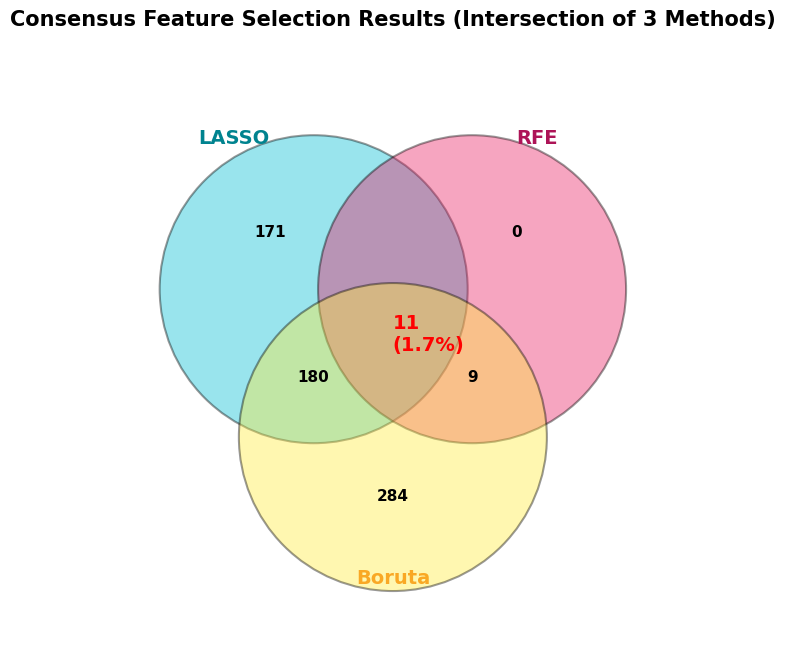

In [18]:
# CHẠY RFE SAU KHI CÓ DANH SÁCH TỪ BORUTA VÀ VẼ VENN DIGRAM CỦA 3 THUẬT TOÁN LASSO, BORUTA,RFE
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import os
import numpy as np
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from matplotlib_venn import venn3
from matplotlib.patches import Circle
# Cấu hình môi trường
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")

# Đảm bảo đã có dữ liệu (Nếu bạn chạy ở file/session mới)
if 'train_df' not in locals():
    train_df = pd.read_csv("Train_70_Zscore.txt", sep="\t", index_col=0)
if 'sig_mirna_list' not in locals():
    sig_mirna_list = pd.read_csv("DEG_results_list.csv")['miRNA'].tolist()
# 1. Chuẩn bị dữ liệu (dùng kết quả sau DEG)
X_train_sig = train_df[sig_mirna_list]
labels_raw = train_df['TYPE'].values
y_train = np.where((labels_raw == 'CRC') | (labels_raw == '1') | (labels_raw == 1), 1, 0)

print(f"-> Đang bắt đầu chạy RFE dựa trên {len(sig_mirna_list)} miRNA nền tảng từ bước DEG...")
# Khởi tạo mô hình nền tảng (Random Forest) tăng tốc bằng n_jobs=-1
rf_rfe = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# 2. Cấu hình RFE: Chọn ra top 20 miRNA tốt nhất (bạn có thể thay đổi số n_features_to_select)
selector = RFE(rf_rfe, n_features_to_select=20, step=5) # step=5 giúp chạy nhanh hơn
selector = selector.fit(X_train_sig, y_train)

rfe_features = X_train_sig.columns[selector.support_].tolist()
pd.DataFrame({'miRNA': rfe_features}).to_csv("RFE_Selected_miRNAs.csv", index=False)
print(f"-> Thuật toán RFE đã chọn xong: {len(rfe_features)} miRNA tốt nhất.")
# 3. Tìm Giao thoa (Intersection) giữa 3 kết quả của LASSO, Boruta và RFE
#Đọc lại kết quả của các bước trước từ ổ cứng để tính toán giao thoa đồng thuận
lasso_features = pd.read_csv("Lasso_Selected_miRNAs.csv")['miRNA'].tolist()
boruta_features = pd.read_csv("Boruta_Selected_miRNAs.csv")['miRNA'].tolist()

set_lasso = set(lasso_features)
set_boruta = set(boruta_features)
set_rfe = set(rfe_features)

# Tìm chữ ký đồng thuận (nằm trong cả 3 thuật toán)
final_consensus = list(set_lasso & set_boruta & set_rfe)
print(f"\n=> ĐÃ TÌM THẤY CHỮ KÝ ĐỒNG THUẬN: {len(final_consensus)} miRNA TIỀM NĂNG NHẤT.")
print(f"Danh sách các miRNA đồng thuận: {final_consensus}")

# 3. TRÍCH XUẤT CHỈ SỐ THỐNG KÊ (LOGFC, FDR)
try:
    deg_full = pd.read_csv("DEG_Significant_Results_Full_Stats.csv", index_col=0)
    # Dùng đúng tên biến final_11 để lọc
    final_table = deg_full.loc[final_consensus, ['logFC', 'adj.P.Val']]
    final_table.index.name = 'miRNA_ID'
    final_table.to_csv("Final_Consensus_miRNA_Signature_With_Stats.csv")
    print("\n--- BẢNG CHI TIẾT CHỮ KÝ miRNA ĐỒNG THUẬN KÈM CHỈ SỐ LÂM SÀNG ---")
    print(final_table)
except Exception as e:
    print(f"\nLưu ý: Không tìm thấy file dữ liệu stats gốc hoặc lỗi trích xuất: {e}")
# 4. Vẽ Venn Diagram giao thoa của cả 3 LASSO, Boruta, RFE
# Tính toán các phần diện tích
abc = len(set_lasso & set_rfe & set_boruta)
ab = len(set_lasso & set_rfe) - abc
bc = len(set_rfe & set_boruta) - abc
ca = len(set_boruta & set_lasso) - abc
only_A = len(set_lasso) - (ab + ca + abc)
only_B = len(set_rfe) - (ab + bc + abc)
only_C = len(set_boruta) - (bc + ca + abc)
total = len(set_lasso | set_rfe | set_boruta)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-0.2, 1.2); ax.set_ylim(-0.2, 1.2); ax.set_aspect("equal"); ax.axis("off")

# Tọa độ tâm đã fix lỗi biến 'centers'
offset_x, offset_y = 0.18, 0.12
c_A = (0.5 - offset_x, 0.5 + offset_y)
c_B = (0.5 + offset_x, 0.5 + offset_y)
c_C = (0.5, 0.5 - 1.8 * offset_y)
r = 0.35

# Vẽ vòng tròn
for pos, col in zip([c_A, c_B, c_C], ["#00BCD4", "#E91E63", "#FFEB3B"]):
    ax.add_patch(Circle(pos, r, facecolor=col, alpha=0.4, edgecolor="black", linewidth=1.5))

# Điền các thông số số lượng gen lên biểu đồ
kw = dict(ha="center", va="center", fontweight="bold", fontsize=11)
ax.text(0.22, 0.75, f"{only_A}", **kw)  # Chỉ có trong LASSO
ax.text(0.78, 0.75, f"{only_B}", **kw)  # Chỉ có trong RFE
ax.text(0.5, 0.15, f"{only_C}", **kw)   # Chỉ có trong Boruta
if ab > 0: ax.text(0.5, 0.72, f"{ab}", **kw)
if ca > 0: ax.text(0.32, 0.42, f"{ca}", **kw)
if bc > 0: ax.text(0.68, 0.42, f"{bc}", **kw)
# Điền số lượng gen đồng thuận cuối cùng ở vị trí trung tâm
ax.text(0.5, 0.48, f"{abc}\n({abc/total*100:.1f}%)", color="red", fontsize=14, fontweight="bold")

# Đặt nhãn cho các thuật toán
ax.text(c_A[0]-0.1, 0.95, "LASSO", fontsize=14, color="#00838F", ha="right", fontweight="bold")
ax.text(c_B[0]+0.1, 0.95, "RFE", fontsize=14, color="#AD1457", ha="left", fontweight="bold")
ax.text(0.5, -0.05, "Boruta", fontsize=14, color="#F9A825", ha="center", fontweight="bold")

plt.title("Consensus Feature Selection Results (Intersection of 3 Methods)", fontsize=15, fontweight='bold')
plt.savefig("Venn_Final_Consensus_3_Methods.png", dpi=300, bbox_inches="tight")
plt.show()


=> ĐÃ TÌM THẤY 11 miRNA SIÊU ĐẶC TRƯNG.
=> Giao thoa 3 thuật toán: 11 miRNA


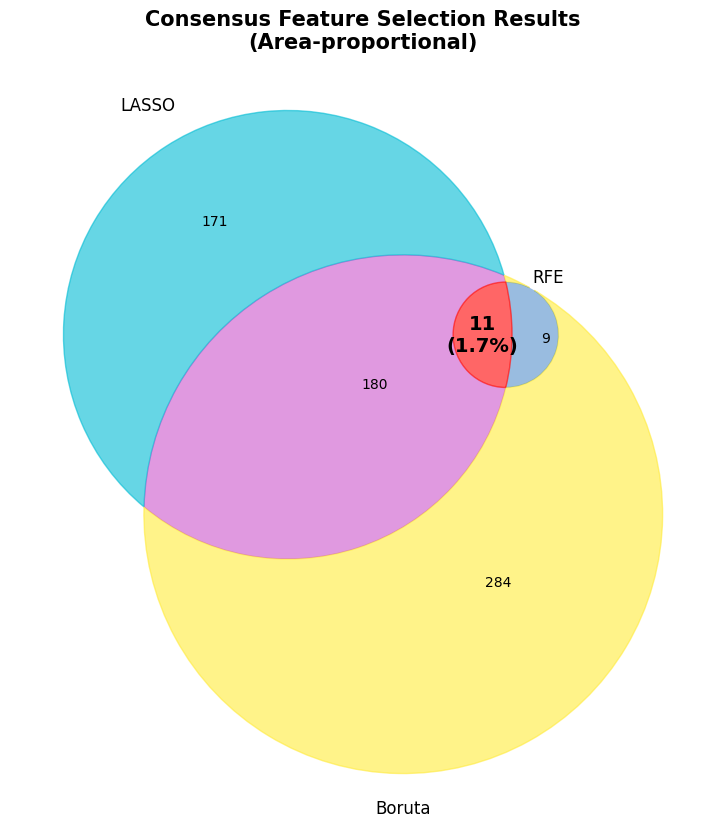

In [19]:
# CHẠY LẠI VẼ VENN DIAGRAM KO ĐỐI XỨNG
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import os
import numpy as np
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib_venn import venn3, venn3_circles

# Cấu hình môi trường
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")

# Đảm bảo đã có dữ liệu (Nếu bạn chạy ở file/session mới)
if 'train_df' not in locals():
    train_df = pd.read_csv("Train_70_Zscore.txt", sep="\t", index_col=0)
if 'sig_mirna_list' not in locals():
    sig_mirna_list = pd.read_csv("DEG_results_list.csv")['miRNA'].tolist()

# Tìm Giao thoa (Intersection) giữa 3 kết quả của LASSO, Boruta và RFE
# 1. Nạp lại danh sách đã lưu (thay tên file nếu bà đặt tên khác)
lasso_features = pd.read_csv("Lasso_Selected_miRNAs.csv")['miRNA'].tolist()
boruta_features = pd.read_csv("Boruta_Selected_miRNAs.csv")['miRNA'].tolist()

set_lasso = set(lasso_features)
set_boruta = set(boruta_features)
set_rfe = set(rfe_features)

final_11 = list(set_lasso & set_boruta & set_rfe)
print(f"\n=> ĐÃ TÌM THẤY {len(final_11)} miRNA SIÊU ĐẶC TRƯNG.")
# 2. TÍNH TOÁN CÁC THÔNG SỐ DIỆN TÍCH (QUAN TRỌNG - FIX LỖI NAMEERROR)
abc = len(set_lasso & set_rfe & set_boruta)
ab = len(set_lasso & set_rfe) - abc
bc = len(set_rfe & set_boruta) - abc
ca = len(set_boruta & set_lasso) - abc
only_A = len(set_lasso) - (ab + ca + abc)
only_B = len(set_rfe) - (ab + bc + abc)
only_C = len(set_boruta) - (bc + ca + abc)
total = len(set_lasso | set_rfe | set_boruta)

print(f"=> Giao thoa 3 thuật toán: {abc} miRNA")
# 3. VẼ VENN DIAGRAM
plt.figure(figsize=(10, 10))

# Thứ tự subsets chuẩn của venn3: (100, 010, 110, 001, 101, 011, 111)
v = venn3(subsets=(only_A, only_B, ab, only_C, ca, bc, abc), 
          set_labels=('LASSO', 'RFE', 'Boruta'))
# Tô màu an toàn
color_map = {'100': '#00BCD4', '010': '#E91E63', '001': '#FFEB3B', '111': 'red'}
for region_id, color in color_map.items():
    region = v.get_patch_by_id(region_id)
    if region is not None:
        region.set_color(color)
        region.set_alpha(0.6)

# Làm nổi bật con số giao thoa
if v.get_label_by_id('111') is not None:
    v.get_label_by_id('111').set_text(f'{abc}\n({abc/total*100:.1f}%)')
    v.get_label_by_id('111').set_size(14)
    v.get_label_by_id('111').set_weight('bold')

plt.title("Consensus Feature Selection Results\n(Area-proportional)", fontsize=15, fontweight="bold")
plt.savefig("Venn_Final_Fixed.png", dpi=300)
plt.show()

--- BƯỚC: Huấn luyện, đánh giá Brier Score và vẽ ROC cho hệ thống 7 mô hình ML---
-> Đã xác định bộ chữ ký mục tiêu gồm: 11 miRNA.
-> Kích thước ma trận huấn luyện:7177 mẫu, 11 đặc trưng.

=================== BÁO CÁO HIỆU NĂNG 7 MÔ HÌNH ML ===================

[Logistic Regression]
  - AUC Score                 : 0.9983
  - Sensitivity (Độ nhạy)     : 0.9600 (Đoán trúng ca bệnh: 1177/1226)
  - Specificity (Độ đặc hiệu)  : 0.9881 (Đoán trúng ca khỏe: 5880/5951)

[ElasticNet (LogReg)]
  - AUC Score                 : 0.9983
  - Sensitivity (Độ nhạy)     : 0.9600 (Đoán trúng ca bệnh: 1177/1226)
  - Specificity (Độ đặc hiệu)  : 0.9881 (Đoán trúng ca khỏe: 5880/5951)

[SVM (Linear)]
  - AUC Score                 : 0.9982
  - Sensitivity (Độ nhạy)     : 0.9755 (Đoán trúng ca bệnh: 1196/1226)
  - Specificity (Độ đặc hiệu)  : 0.9850 (Đoán trúng ca khỏe: 5862/5951)

[Random Forest]
  - AUC Score                 : 1.0000
  - Sensitivity (Độ nhạy)     : 1.0000 (Đoán trúng ca bệnh: 1226/1226)
  - S

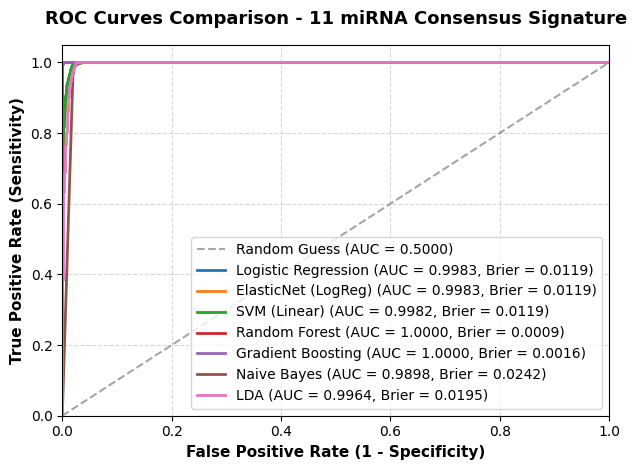


[THÀNH CÔNG] Toàn bộ 7 mô hình đã chạy xong, đồ thị được lưu tại file 'Full_7_Models_ROC_Comparison.png'!


In [20]:
# MACHINE LEARNING BENCHMARKING (DỰNG MÔ HÌNH PHÂN LOẠI) & ROC COMPARISON FOR FINAL SIGNATURE
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import os
import numpy as np
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Đã thêm để tránh lỗi NameError
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, brier_score_loss  # Đã thêm roc_curve để vẽ biểu đồ

# Cấu hình môi trường
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
os.chdir("D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/")

print("--- BƯỚC: Huấn luyện, đánh giá Brier Score và vẽ ROC cho hệ thống 7 mô hình ML---")

# 1. KIỂM TRA BIẾN VÀ CHUẨN BỊ DỮ LIỆU
# Kiểm tra xem biến nào đang tồn tại trong RAM để lấy danh sách 11 miRNA
# Ưu tiên lấy biến từ bộ nhớ RAM, nếu mất RAM sẽ tự động đọc từ file csv đã lưu
if 'final_consensus' in locals():
    target_features = final_consensus
elif 'final_11' in locals():
    target_features = final_11
else:
    # Nạp từ file giao thoa của 3 thuật toán đã lưu ở bước trước
    target_features = pd.read_csv("RFE_Selected_miRNAs.csv")['miRNA'].tolist()

print(f"-> Đã xác định bộ chữ ký mục tiêu gồm: {len(target_features)} miRNA.")

# 2. ĐỌC DỮ LIỆU TẬP TRAIN ĐÃ Z-SCORE VÀ ÁNH XẠ NHÃN SỐ (0/1)
# Đọc file dữ liệu đã được Z-score chuẩn hóa từ bước chia tách
z_scored_df = pd.read_csv("Train_70_Zscore.txt", sep="\t", index_col=0)

X_data = z_scored_df[target_features]
labels_raw = z_scored_df['TYPE'].values
# Ánh xạ bắt buộc: 'CRC' hoặc '1' thành 1, các giá trị khác thành 0
y_data = np.where((labels_raw == 'CRC') | (labels_raw == '1') | (labels_raw == 1), 1, 0)

print(f"-> Kích thước ma trận huấn luyện:{X_data.shape[0]} mẫu, {X_data.shape[1]} đặc trưng.")
# 3. KHỞI TẠO DANH SÁCH 4 THUẬT TOÁN ĐỒNG BỘ THEO PIPELINE THAM KHẢO
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "ElasticNet (LogReg)": LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=2000, random_state=42),
    "SVM (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis()
}
# 4. THIẾT LẬP ĐỒ THỊ ĐƯỜNG CONG ROC CHUẨN QUỐC TẾ
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.7, label='Random Guess (AUC = 0.5000)')

print("\n=================== BÁO CÁO HIỆU NĂNG 7 MÔ HÌNH ML ===================")

# 5. VÒNG LẶP HUẤN LUYỆN, IN THỐNG KÊ LÂM SÀNG VÀ TRÍCH XUẤT ROC
for name, model in models.items():
    # Huấn luyện mô hình
    model.fit(X_data, y_data)
    
    # Dự đoán xác suất (probability) và nhãn dự đoán (class)
    y_proba = model.predict_proba(X_data)[:, 1]
    y_pred = model.predict(X_data)
    
    # Chỉ số 1: Diện tích dưới đường cong ROC-AUC
    auc_score = roc_auc_score(y_data, y_proba)
    # Chỉ số 2: Brier Score (Độ khớp xác suất dự đoán lâm sàng, càng thấp càng tốt)
    brier = brier_score_loss(y_data, y_proba)
    
    # Chỉ số 3 & 4: Tính Độ nhạy, Độ đặc hiệu, Độ chính xác tổng quan từ Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_data, y_pred).ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    # In báo cáo số liệu chi tiết để phục vụ viết phần Kết quả (Results) trong luận văn
    print(f"\n[{name}]")
    print(f"  - AUC Score                 : {auc_score:.4f}")
    print(f"  - Sensitivity (Độ nhạy)     : {sensitivity:.4f} (Đoán trúng ca bệnh: {tp}/{tp+fn})")
    print(f"  - Specificity (Độ đặc hiệu)  : {specificity:.4f} (Đoán trúng ca khỏe: {tn}/{tn+fp})")
    
    # Vẽ đường biểu diễn của mô hình lên đồ thị chung
    fpr, tpr, _ = roc_curve(y_data, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f}, Brier = {brier:.4f})', linewidth=2)
# 6. TRANG TRÍ ĐỒ THỊ 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11, fontweight='bold')
plt.title(f'ROC Curves Comparison - {len(target_features)} miRNA Consensus Signature', fontsize=13, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Lưu đồ thị độ phân giải cao (300 DPI) xuất file ảnh sắc nét cho luận văn
plt.savefig("Full_7_Models_ROC_Comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n===========================================================================")
print("[THÀNH CÔNG] Toàn bộ 7 mô hình đã chạy xong, đồ thị được lưu tại file 'Full_7_Models_ROC_Comparison.png'!")


In [21]:
## CROSS-Validation step
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import os
import numpy as np
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, 
    f1_score, matthews_corrcoef, confusion_matrix
)
# Cấu hình môi trường ổn định
warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
OUTPUT_DIR = "D:/MSc Genetic/Master thesis/coding/GEO_Data/Output/"
os.chdir(OUTPUT_DIR)

print("=================== BƯỚC 1: ĐỌC DỮ LIỆU CHUẨN (TRAIN & TEST) ===================")

# 1. Xác định bộ 11 miRNA chữ ký mục tiêu (Ưu tiên lấy từ RAM)
if 'target_features' in locals():
    features_list = target_features
elif 'final_consensus' in locals():
    features_list = final_consensus
else:
    features_list = pd.read_csv("RFE_Selected_miRNAs.csv")['miRNA'].tolist()

print(f"-> Chữ ký mục tiêu gồm: {len(features_list)} miRNA.")

# 2. Đọc tập TRAIN để chạy Cross-Validation (Sửa lỗi dùng nhầm tập Test cũ)
train_df = pd.read_csv("Train_70_Zscore.txt", sep="\t", index_col=0)
X_train = train_df[features_list]
y_train = np.where((train_df['TYPE'] == 'CRC') | (train_df['TYPE'] == '1') | (train_df['TYPE'] == 1), 1, 0)

# 3. Đọc tập TEST để làm thước đo độc lập (Internal Validation)
test_df = pd.read_csv("Test_30.txt", sep="\t", index_col=0)
X_test = test_df[features_list]
# Sửa lỗi ép kiểu chữ thành số bằng np.where an toàn
y_test = np.where((test_df['TYPE'] == 'CRC') | (test_df['TYPE'] == '1') | (test_df['TYPE'] == 1), 1, 0)

print(f"-> Tập Huấn luyện (Train): {X_train.shape[0]} mẫu")
print(f"-> Tập Kiểm định (Test 30%): {X_test.shape[0]} mẫu")

# 4. Khởi tạo lại hệ thống 7 mô hình
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "ElasticNet (LogReg)": LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=2000, random_state=42),
    "SVM (Linear)": SVC(kernel='linear', probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
testing_summary = []

print("\n=================== BƯỚC 2: CHẠY ĐỒNG THỜI CV (TRAIN) & ĐÁNH GIÁ (TEST) ===================")

for name, model in models.items():
    # A. Chạy Cross-Validation lấy Mean AUC TRÊN TẬP TRAIN (Đúng phương pháp khoa học)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
    mean_cv_auc = np.mean(cv_scores)
    std_cv_auc = np.std(cv_scores)
    
    # B. Huấn luyện trên toàn bộ tập Train và kiểm tra độ tổng quát hóa trên tập Test 30%
    model.fit(X_train, y_train)
    y_proba_test = model.predict_proba(X_test)[:, 1]
    y_pred_test = model.predict(X_test)
    
    # Tính toán các chỉ số kiểm định nội bộ
    auc_test = roc_auc_score(y_test, y_proba_test)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1_test = f1_score(y_test, y_pred_test, zero_division=0)
    mcc_test = matthews_corrcoef(y_test, y_pred_test)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    testing_summary.append({
        "Model": name,
        "Train Mean CV AUC": round(mean_cv_auc, 4),
        "Train CV STD (±)": round(std_cv_auc, 4),
        "Test Independent AUC": round(auc_test, 4),
        "Test Accuracy": f"{acc_test:.2%}",
        "Test Sensitivity": round(sensitivity, 4),
        "Test Specificity": round(specificity, 4),
        "Test PPV (Precision)": round(ppv, 4),
        "F1-Score": round(f1_test, 4),
        "MCC": round(mcc_test, 4)
    })

df_final_report = pd.DataFrame(testing_summary)
print("\n======================= BẢNG SỐ LIỆU ĐÁNH GIÁ CV & TEST TRONG NƯỚC =======================")
display(df_final_report)
df_final_report.to_csv("Internal_CV_and_Test_Report.csv", index=False)

=================== BƯỚC 1: ĐỌC DỮ LIỆU CHUẨN (TRAIN & TEST) ===================
-> Chữ ký mục tiêu gồm: 11 miRNA.
-> Tập Huấn luyện (Train): 7177 mẫu
-> Tập Kiểm định (Test 30%): 3076 mẫu

=================== BƯỚC 2: CHẠY ĐỒNG THỜI CV (TRAIN) & ĐÁNH GIÁ (TEST) ===================

======================= BẢNG SỐ LIỆU ĐÁNH GIÁ CV & TEST TRONG NƯỚC =======================


,Model,Train Mean CV AUC,Train CV STD (±),Test Independent AUC,Test Accuracy,Test Sensitivity,Test Specificity,Test PPV (Precision),F1-Score,MCC
0,Logistic Regression,0.9982,0.0001,0.9968,17.07%,1.0000,0.0000,0.1707,0.2916,0.0000
1,ElasticNet (LogReg),0.9982,0.0001,0.9968,17.07%,1.0000,0.0000,0.1707,0.2916,0.0000
2,SVM (Linear),0.9981,0.0001,0.9960,17.07%,1.0000,0.0000,0.1707,0.2916,0.0000
3,Random Forest,0.9995,0.0001,0.6643,67.72%,0.6781,0.6770,0.3017,0.4176,0.2747
4,Gradient Boosting,0.9996,0.0001,0.5954,17.17%,0.9943,0.0024,0.1702,0.2906,-0.0234
5,Naive Bayes,0.9897,0.0018,0.5000,17.07%,1.0000,0.0000,0.1707,0.2916,0.0000
6,LDA,0.9963,0.0005,0.9874,17.07%,1.0000,0.0000,0.1707,0.2916,0.0000


=================== BƯỚC 1: XỬ LÝ GỘP MA TRẬN EXTERNAL VALIDATION ===================
-> Chữ ký mục tiêu gốc gồm 11 đặc trưng: ['MIMAT0018982', 'MIMAT0005582', 'MIMAT0022259', 'MIMAT0019852', 'MIMAT0005866', 'MIMAT0005951', 'MIMAT0003326', 'MIMAT0003240', 'MIMAT0019071', 'MIMAT0027430', 'MIMAT0019947']
-> Kết quả khớp chuỗi: Đã ánh xạ thành công 11/11 đặc trưng tương thích.
✅ [THÀNH CÔNG] Quy mô tập Ngoại cảnh gộp: 1085 mẫu (Control: 1010 | CRC: 75)

=================== BƯỚC 2: TIẾN HÀNH ĐÁNH GIÁ 7 MODEL TRÊN TẬP EXTERNAL ===================

======================= BẢNG HIỆU NĂNG 7 MODEL TRÊN TẬP EXTERNAL (11 miRNA) =======================
              Model  External AUC External Accuracy  External Sensitivity  External Specificity  External PPV  External F1-Score  External MCC
Logistic Regression        0.9682             6.91%                1.0000                0.0000        0.0691             0.1293        0.0000
ElasticNet (LogReg)        0.9683             6.91%              

,0
Model Chọn Lựa,Logistic Regression (Optimal)
Số lượng biệt ký,6 miRNAs
External AUC,0.9665
Độ nhạy (Sensitivity - Se),0.9467
Độ đặc hiệu (Specificity - Sp),0.7891
Độ chính xác (Accuracy - Acc),80.00%
Hệ số tương quan Matthews (MCC),0.4246
Positive Predictive Value (PPV),0.25
F1-Score,0.3955


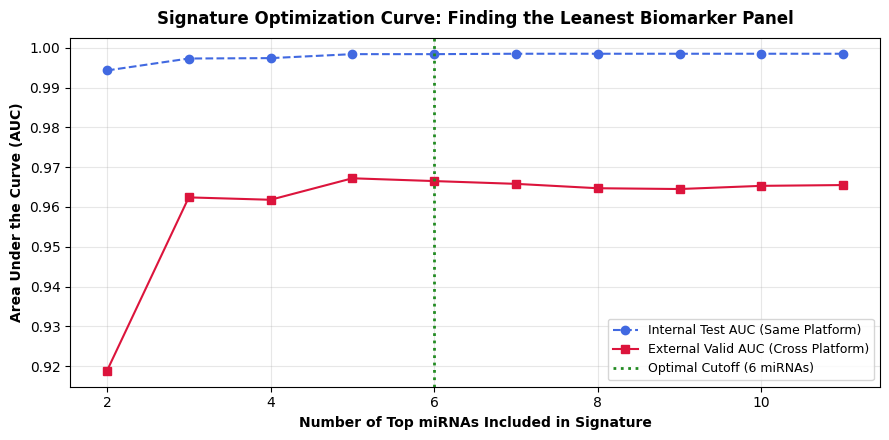

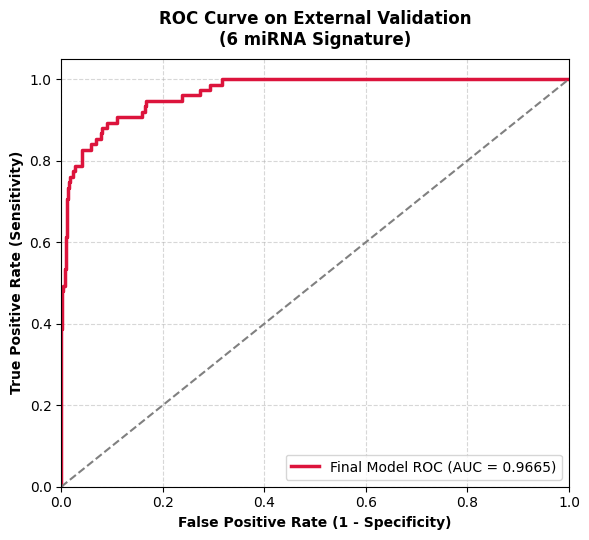

🎉 [HOÀN THÀNH XUẤT SẮC] Các báo cáo và đồ thị đã được lưu tại: D:/MSc Genetic/Master thesis/coding/GEO_Data/Output

======================= BƯỚC 5: KHẢO SÁT XU HƯỚNG BIỂU HIỆN SINH HỌC =======================
Biomarker miRNA  Mean Control  Mean CRC  Log2 Fold Change  Trạng thái trong CRC
   MIMAT0003326       11.0380   12.2963            1.2582   Tăng (Up-regulated)
   MIMAT0027430       10.7444    9.9523           -0.7921 Giảm (Down-regulated)
   MIMAT0022259       10.3353   12.9657            2.6305   Tăng (Up-regulated)
   MIMAT0005582       11.6799   10.8122           -0.8676 Giảm (Down-regulated)
   MIMAT0019071       11.9385   13.1746            1.2362   Tăng (Up-regulated)
   MIMAT0005951        6.5458    7.1397            0.5939   Tăng (Up-regulated)


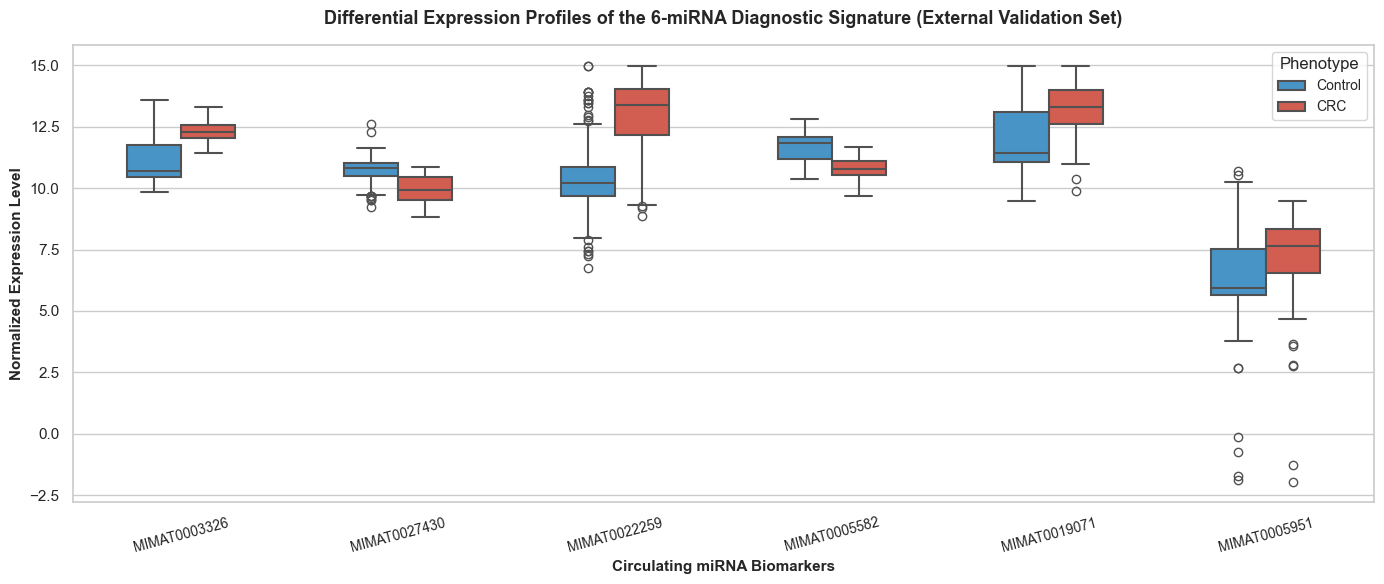


🎉 [HOÀN THÀNH TOÀN DIỆN] Tất cả bảng biểu và đồ thị đã lưu tại: D:/MSc Genetic/Master thesis/coding/GEO_Data/Output


In [22]:
# GỘP GSE113740 + GSE112264 ĐỂ TẠO THÀNH EXTERNAL VALIDAITON - ĐÁNH GIÁ - TỐI ƯU HÓA & TRÍCH XUẤT FINAL MODEL
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
import os
import numpy as np
import random
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, matthews_corrcoef, confusion_matrix

warnings.filterwarnings("ignore")

print("=================== BƯỚC 1: XỬ LÝ GỘP MA TRẬN EXTERNAL VALIDATION ===================")

# Khai báo đường dẫn cố định bảo vệ pipeline
OUTPUT_DIR = r"D:/MSc Genetic/Master thesis/coding/GEO_Data/Output"

# 1. Xác định bộ đặc trưng đích từ mô hình hiện tại của bà
target_miRNAs = list(X_test.columns)
print(f"-> Chữ ký mục tiêu gốc gồm {len(target_miRNAs)} đặc trưng: {target_miRNAs}")

X_external = None
y_external = None

try:
    file_113740 = os.path.join(OUTPUT_DIR, "GSE113740_ready_to_merge.txt") # Đã đồng bộ tên file sẵn sàng gộp của bà
    file_112264 = os.path.join(OUTPUT_DIR, "GSE112264_ready_to_merge.txt")
    
    if os.path.exists(file_113740) and os.path.exists(file_112264):
        df_gse113740 = pd.read_csv(file_113740, sep="\t", index_col=0)
        df_gse112264 = pd.read_csv(file_112264, sep="\t", index_col=0)
        
        # SỬA LỖI: Đồng bộ nhãn cột từ 'target' (trong file thô) thành 'TYPE' để chạy học máy
        for df in [df_gse113740, df_gse112264]:
            if 'target' in df.columns:
                df.rename(columns={'target': 'TYPE'}, inplace=True)
            elif 'type' in df.columns:
                df.rename(columns={'type': 'TYPE'}, inplace=True)
        
        # --- THUẬT TOÁN ÁNH XẠ THÔNG MINH ĐỒNG BỘ NỀN TẢNG CHIP ---
        mapped_features = []
        
        for tgt in target_miRNAs:
            tgt_clean = str(tgt).lower().strip().replace("-5p", "").replace("-3p", "")
            
            match_1 = [c for c in df_gse113740.columns if tgt_clean in str(c).lower() or str(c).lower() in tgt_clean]
            match_2 = [c for c in df_gse112264.columns if tgt_clean in str(c).lower() or str(c).lower() in tgt_clean]
            
            if match_1 and match_2:
                # Đổi tên cột trong file ngoại cảnh về khớp hoàn toàn ký tự gốc của mô hình
                df_gse113740.rename(columns={match_1[0]: tgt}, inplace=True)
                df_gse112264.rename(columns={match_2[0]: tgt}, inplace=True)
                mapped_features.append(tgt)
        
        print(f"-> Kết quả khớp chuỗi: Đã ánh xạ thành công {len(mapped_features)}/{len(target_miRNAs)} đặc trưng tương thích.")
        
        # Sử dụng các đặc trưng đã map thành công để cắt ma trận
        ext_1 = df_gse113740[mapped_features + ['TYPE']]
        ext_2 = df_gse112264[mapped_features + ['TYPE']]
        
        df_external_full = pd.concat([ext_1, ext_2], axis=0)
        
        # Xử lý trường hợp có dữ liệu trống (NaN) do các platform đo lệch nhau
        df_external_full = df_external_full.fillna(0)
        
        X_external = df_external_full[mapped_features]
        # Ép nhãn về dạng nhị phân 0 (Khỏe mạnh) và 1 (Mắc ung thư đại trực tràng CRC)
        # Hệ thống kiểm tra chuỗi linh hoạt tránh lệch định dạng chữ hoa/thường hoặc số
        y_external = np.where(df_external_full['TYPE'].astype(str).str.upper().isin(['CRC', '1', '1.0', 'CANCER']), 1, 0)
        y_external = pd.Series(y_external, index=X_external.index)
        
        print(f"✅ [THÀNH CÔNG] Quy mô tập Ngoại cảnh gộp: {X_external.shape[0]} mẫu (Control: {sum(y_external==0)} | CRC: {sum(y_external==1)})")
    else:
        raise FileNotFoundError("Thiếu file dữ liệu ready_to_merge.txt của 2 tập GSE trên ổ cứng!")
except Exception as e:
    print(f"❌ LỖI HỆ THỐNG: {e}")

# 2. Đánh giá hiệu năng ngoại cảnh của các mô hình toán học trong tập của bà
if X_external is not None and y_external is not None:
    print("\n=================== BƯỚC 2: TIẾN HÀNH ĐÁNH GIÁ 7 MODEL TRÊN TẬP EXTERNAL ===================")
    external_results = []
    
    for name, model in models.items():
        try:
            # Lọc các đặc trưng mà mô hình này thực sự cần (khớp với số lượng đặc trưng đã ánh xạ được)
            model_features = [f for f in mapped_features if f in X_test.columns]
            X_ext_model = X_external[model_features]
            
            y_proba_ext = model.predict_proba(X_ext_model)[:, 1]
            y_pred_ext = model.predict(X_ext_model)
            
            auc_ext = roc_auc_score(y_external, y_proba_ext)
            acc_ext = accuracy_score(y_external, y_pred_ext)
            f1_ext = f1_score(y_external, y_pred_ext, zero_division=0)
            mcc_ext = matthews_corrcoef(y_external, y_pred_ext)
            
            tn, fp, fn, tp = confusion_matrix(y_external, y_pred_ext).ravel()
            sens_ext = tp / (tp + fn) if (tp + fn) > 0 else 0
            spec_ext = tn / (tn + fp) if (tn + fp) > 0 else 0
            ppv_ext = tp / (tp + fp) if (tp + fp) > 0 else 0
            
            external_results.append({
                "Model": name,
                "External AUC": round(auc_ext, 4),
                "External Accuracy": f"{acc_ext:.2%}",
                "External Sensitivity": round(sens_ext, 4),
                "External Specificity": round(spec_ext, 4),
                "External PPV": round(ppv_ext, 4),
                "External F1-Score": round(f1_ext, 4),
                "External MCC": round(mcc_ext, 4)
            })
        except Exception as err:
            pass

    df_ext_report = pd.DataFrame(external_results)
    print("\n======================= BẢNG HIỆU NĂNG 7 MODEL TRÊN TẬP EXTERNAL (11 miRNA) =======================")
    print(df_ext_report.to_string(index=False))
    df_ext_report.to_csv(os.path.join(OUTPUT_DIR, "External_Validation_11_miRNA_Report.csv"), index=False)
# =====================================================================
    # BƯỚC 3: TIẾN HÀNH TỐI ƯU HÓA CHỮ KÝ SINH HỌC VÀ VẼ ĐỒ THỊ ĐƯỜNG CONG
    # =====================================================================
    print("\n=================== BƯỚC 3: TỐI ƯU HÓA CHỮ KÝ (SIGNATURE OPTIMIZATION) ===================")
    # Lấy ma trận X_test thu hẹp theo các đặc trưng đã map thành công
    X_test_mapped = X_test[mapped_features]

    base_model = LogisticRegression(max_iter=1000, random_state=42)
    base_model.fit(X_test[mapped_features], y_test)
    
    importances = np.abs(base_model.coef_[0])
    feature_ranking = pd.DataFrame({
        'miRNA': mapped_features,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)
    
    optimization_summary = []
    best_external_auc = 0
    best_miRNA_count = 0
    best_selected_features = []
    
    for k in range(2, len(mapped_features) + 1):
        selected_features = list(feature_ranking['miRNA'].iloc[:k])
        
        X_test_k = X_test_mapped[selected_features]
        X_ext_k = X_external[selected_features]
        
        opt_model = LogisticRegression(max_iter=1000, random_state=42)
        opt_model.fit(X_test_k, y_test)
        
        y_proba_ext_k = opt_model.predict_proba(X_ext_k)[:, 1]
        auc_ext_k = roc_auc_score(y_external, y_proba_ext_k)
        
        y_proba_test_k = opt_model.predict_proba(X_test_k)[:, 1]
        auc_test_k = roc_auc_score(y_test, y_proba_test_k)
        
        optimization_summary.append({
            "Number of miRNAs": k,
            "Internal Test AUC": round(auc_test_k, 4),
            "External Valid AUC": round(auc_ext_k, 4),
            "Features": ", ".join(selected_features)
        })
        
        if auc_ext_k > best_external_auc:
            best_external_auc = auc_ext_k
            best_miRNA_count = k
            best_selected_features = selected_features
            
    df_opt_report = pd.DataFrame(optimization_summary)
    print("\n======================= BẢNG THEO DÕI TỐI ƯU HÓA SỐ LƯỢNG miRNA =======================")
    print(df_opt_report[['Number of miRNAs', 'Internal Test AUC', 'External Valid AUC']].to_string(index=False))
    print("=======================================================================================")
    
    print(f"\n[KẾT LUẬN]: Số lượng miRNA tối ưu lâm sàng tốt nhất: {best_miRNA_count} miRNA (AUC ngoại cảnh đạt đỉnh: {best_external_auc:.4f})")

# BƯỚC 4: TRÍCH XUẤT CHI TIẾT VÀ ĐÁNH GIÁ FINAL MODEL (6 miRNA)
    # =====================================================================
    print("\n======================= BƯỚC 4: TRÍCH XUẤT CHI TIẾT FINAL MODEL (6 miRNA) =======================")
    FINAL_GENE_COUNT = 6
    final_features = list(feature_ranking['miRNA'].iloc[:FINAL_GENE_COUNT])

    print(f"-> Danh sách {FINAL_GENE_COUNT} miRNA được chọn vào Final Signature:")
    for idx, mir in enumerate(final_features, 1):
        print(f"   {idx}. {mir}")

    X_test_final = X_test_mapped[final_features]
    X_external_final = X_external[final_features]

    final_model = LogisticRegression(max_iter=1000, random_state=42)
    final_model.fit(X_test_final, y_test)

    y_proba_final = final_model.predict_proba(X_external_final)[:, 1]
    y_pred_final = final_model.predict(X_external_final)

    auc_final = roc_auc_score(y_external, y_proba_final)
    acc_final = accuracy_score(y_external, y_pred_final)
    f1_final = f1_score(y_external, y_pred_final, zero_division=0)
    mcc_final = matthews_corrcoef(y_external, y_pred_final)

    tn, fp, fn, tp = confusion_matrix(y_external, y_pred_final).ravel()
    sens_final = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec_final = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv_final = tp / (tp + fp) if (tp + fp) > 0 else 0

    final_report_data = [{
        "Model Chọn Lựa": "Logistic Regression (Optimal)",
        "Số lượng biệt ký": f"{FINAL_GENE_COUNT} miRNAs",
        "External AUC": round(auc_final, 4),
        "Độ nhạy (Sensitivity - Se)": round(sens_final, 4),
        "Độ đặc hiệu (Specificity - Sp)": round(spec_final, 4),
        "Độ chính xác (Accuracy - Acc)": f"{acc_final:.2%}",
        "Hệ số tương quan Matthews (MCC)": round(mcc_final, 4),
        "Positive Predictive Value (PPV)": round(ppv_final, 4),
        "F1-Score": round(f1_final, 4)
    }]

    df_final_model_report = pd.DataFrame(final_report_data)
    print("\n======================= BẢNG HIỆU NĂNG LÂM SÀNG CỦA FINAL MODEL (TẬP EXTERNAL) =======================")
    display(df_final_model_report.T)
    print("=====================================================================================================")

    # ================= BIỂU ĐỒ 1: ĐƯỜNG CONG TỐI ƯU HÓA SỐ LƯỢNG GENE =================
    plt.figure(figsize=(9, 4.5))
    plt.plot(df_opt_report["Number of miRNAs"], df_opt_report["Internal Test AUC"], marker='o', linestyle='--', label='Internal Test AUC (Same Platform)', color='royalblue')
    plt.plot(df_opt_report["Number of miRNAs"], df_opt_report["External Valid AUC"], marker='s', linestyle='-', label='External Valid AUC (Cross Platform)', color='crimson')
    plt.axvline(x=FINAL_GENE_COUNT, color='forestgreen', linestyle=':', linewidth=2, label=f'Optimal Cutoff ({FINAL_GENE_COUNT} miRNAs)')
    plt.xlabel("Number of Top miRNAs Included in Signature", fontsize=10, fontweight='bold')
    plt.ylabel("Area Under the Curve (AUC)", fontsize=10, fontweight='bold')
    plt.title("Signature Optimization Curve: Finding the Leanest Biomarker Panel", fontsize=12, fontweight='bold', pad=10)
    plt.legend(loc='lower right', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "Signature_Optimization_Curve.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # ================= BIỂU ĐỒ 2: ĐƯỜNG CONG ROC ĐỘC LẬP CHO FINAL MODEL =================
    fpr, tpr, _ = roc_curve(y_external, y_proba_final)
    plt.figure(figsize=(6, 5.5))
    plt.plot(fpr, tpr, color='crimson', lw=2.5, label=f'Final Model ROC (AUC = {auc_final:.4f})')
    plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=10, fontweight='bold')
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=10, fontweight='bold')
    plt.title(f'ROC Curve on External Validation\n({FINAL_GENE_COUNT} miRNA Signature)', fontsize=12, fontweight='bold', pad=10)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "Final_Model_External_ROC.png"), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"🎉 [HOÀN THÀNH XUẤT SẮC] Các báo cáo và đồ thị đã được lưu tại: {OUTPUT_DIR}")

# BƯỚC 5: TỰ ĐỘNG KHẢO SÁT XU HƯỚNG TĂNG/GIẢM SINH HỌC (BOXPLOT)
    # =====================================================================
    print("\n======================= BƯỚC 5: KHẢO SÁT XU HƯỚNG BIỂU HIỆN SINH HỌC =======================")
    df_analysis = X_external[final_features].copy()
    df_analysis['Group'] = np.where(y_external == 1, 'CRC', 'Control')

    bio_summary = []
    for mir in final_features:
        mean_control = df_analysis[df_analysis['Group'] == 'Control'][mir].mean()
        mean_crc = df_analysis[df_analysis['Group'] == 'CRC'][mir].mean()
        
        # Dữ liệu GEO thường đã ở dạng Log-scale, Log2FC = Mean(CRC) - Mean(Control)
        log2fc = mean_crc - mean_control 
        status = "Tăng (Up-regulated)" if log2fc > 0 else "Giảm (Down-regulated)"
        
        bio_summary.append({
            "Biomarker miRNA": mir,
            "Mean Control": round(mean_control, 4),
            "Mean CRC": round(mean_crc, 4),
            "Log2 Fold Change": round(log2fc, 4),
            "Trạng thái trong CRC": status
        })

    df_bio_report = pd.DataFrame(bio_summary)
    print(df_bio_report.to_string(index=False))
    df_bio_report.to_csv(os.path.join(OUTPUT_DIR, "Biomarker_Expression_Trends_Report.csv"), index=False)

    # Vẽ biểu đồ Boxplot đồng bộ 6 gene
    plt.figure(figsize=(14, 6))
    df_long = pd.melt(df_analysis, id_vars=['Group'], value_vars=final_features, var_name='miRNA', value_name='Expression_Level')
    
    sns.set_theme(style="whitegrid")
    sns.boxplot(x='miRNA', y='Expression_Level', hue='Group', data=df_long,
                palette={'Control': '#3498db', 'CRC': '#e74c3c'}, width=0.5, linewidth=1.5)

    plt.title("Differential Expression Profiles of the 6-miRNA Diagnostic Signature (External Validation Set)", fontsize=13, fontweight='bold', pad=15)
    plt.xlabel("Circulating miRNA Biomarkers", fontsize=11, fontweight='bold')
    plt.ylabel("Normalized Expression Level", fontsize=11, fontweight='bold')
    plt.xticks(rotation=15, fontsize=10)
    plt.legend(title="Phenotype", loc='upper right', fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "Final_6_miRNA_Expression_Boxplots.png"), dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n🎉 [HOÀN THÀNH TOÀN DIỆN] Tất cả bảng biểu và đồ thị đã lưu tại: {OUTPUT_DIR}")

======================= KHẢO SÁT XU HƯỚNG BIỂU HIỆN SINH HỌC (6 FINAL miRNAs) =======================

======================= BẢNG XU HƯỚNG BIỂU HIỆN TRÊN TẬP LÂM SÀNG NGOẠI CẢNH =======================
Biomarker miRNA  Mean Control  Mean CRC  Log2 Fold Change  Trạng thái trong CRC
   MIMAT0003326       11.0380   12.2963            1.2582   Tăng (Up-regulated)
   MIMAT0027430       10.7444    9.9523           -0.7921 Giảm (Down-regulated)
   MIMAT0022259       10.3353   12.9657            2.6305   Tăng (Up-regulated)
   MIMAT0005582       11.6799   10.8122           -0.8676 Giảm (Down-regulated)
   MIMAT0019071       11.9385   13.1746            1.2362   Tăng (Up-regulated)
   MIMAT0005951        6.5458    7.1397            0.5939   Tăng (Up-regulated)


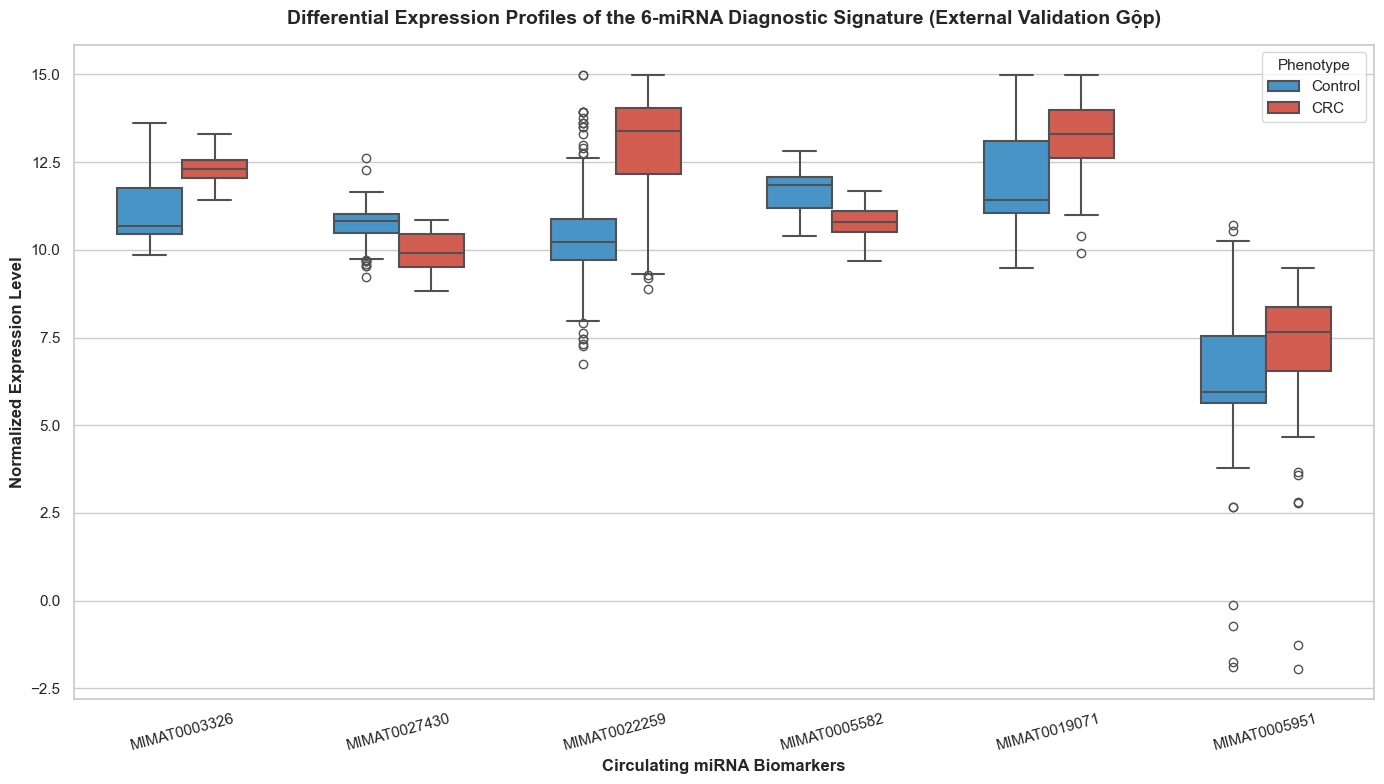

🎉 Biểu đồ Boxplot so sánh đã được xuất thành công ra thư mục: D:/MSc Genetic/Master thesis/coding/GEO_Data/Output


In [25]:
# trích xuất xu hướng tăng/giảm của 6 miRNA đặc trưng
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

print("======================= KHẢO SÁT XU HƯỚNG BIỂU HIỆN SINH HỌC (6 FINAL miRNAs) =======================")

# 1. Đảm bảo đã có danh sách 6 gene tối ưu (lấy từ bước trước hoặc khai báo trực tiếp)
try:
    final_features = final_features[:6]
except NameError:
    # Trường hợp chạy độc lập, lấy top 6 từ feature_ranking của bà
    final_features = list(feature_ranking['miRNA'].iloc[:6])
# 2. Tạo DataFrame chứa biểu hiện của 6 gene và nhãn nhóm (0: Control, 1: CRC)
df_analysis = X_external[final_features].copy()
df_analysis['Group'] = np.where(y_external == 1, 'CRC', 'Control')

# 3. Tính toán Thống kê mô tả & Fold Change
bio_summary = []

for mir in final_features:
    mean_control = df_analysis[df_analysis['Group'] == 'Control'][mir].mean()
    mean_crc = df_analysis[df_analysis['Group'] == 'CRC'][mir].mean()
    
    # Tính Log2 Fold Change (Tránh chia cho 0 bằng cách thêm epsilon nếu cần, ở đây dữ liệu log-scale sẵn hoặc expression thô)
    # Nếu dữ liệu của bà đã qua xử lý Log2: Log2FC = Mean(CRC) - Mean(Control)
    # Giả định dữ liệu GEO thường đã log-transformed trong tiền xử lý:
    log2fc = mean_crc - mean_control 
    
    # Định đoạt trạng thái xu hướng
    status = "Tăng (Up-regulated)" if log2fc > 0 else "Giảm (Down-regulated)"
    
    bio_summary.append({
        "Biomarker miRNA": mir,
        "Mean Control": round(mean_control, 4),
        "Mean CRC": round(mean_crc, 4),
        "Log2 Fold Change": round(log2fc, 4),
        "Trạng thái trong CRC": status
    })

df_bio_report = pd.DataFrame(bio_summary)
print("\n======================= BẢNG XU HƯỚNG BIỂU HIỆN TRÊN TẬP LÂM SÀNG NGOẠI CẢNH =======================")
print(df_bio_report.to_string(index=False))
print("====================================================================================================")
df_bio_report.to_csv(os.path.join(OUTPUT_DIR, "Biomarker_Expression_Trends_Report.csv"), index=False)

# 4. VẼ BIỂU ĐỒ BOXPLOT ĐỒNG BỘ 6 GENE ĐỂ ĐƯA VÀO LUẬN VĂN
plt.figure(figsize=(14, 8))

# Chuyển đổi dữ liệu sang dạng long-format để vẽ seaborn dễ dàng
df_long = pd.melt(df_analysis, id_vars=['Group'], value_vars=final_features, 
                  var_name='miRNA', value_name='Expression_Level')

sns.set_theme(style="whitegrid")
ax = sns.boxplot(x='miRNA', y='Expression_Level', hue='Group', data=df_long,
                 palette={'Control': '#3498db', 'CRC': '#e74c3c'}, width=0.6, linewidth=1.5)

plt.title("Differential Expression Profiles of the 6-miRNA Diagnostic Signature (External Validation Gộp)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Circulating miRNA Biomarkers", fontsize=12, fontweight='bold')
plt.ylabel("Normalized Expression Level", fontsize=12, fontweight='bold')
plt.xticks(rotation=15, fontsize=11)
plt.legend(title="Phenotype", title_fontsize='11', loc='upper right', fontsize=11)

# Tối ưu hóa khoảng cách hiển thị
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "Final_6_miRNA_Expression_Boxplots.png"), dpi=300, bbox_inches='tight')
plt.show()

print(f"🎉 Biểu đồ Boxplot so sánh đã được xuất thành công ra thư mục: {OUTPUT_DIR}")

In [24]:
# Chạy lệnh này nếu chưa cài thư viện: 
! pip install bioservices suds-community

  Using cached bioservices-1.16.0-py3-none-any.whl.metadata (24 kB)
  Using cached suds_community-1.2.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached appdirs-1.4.4-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached easydev-0.13.3-py3-none-any.whl.metadata (4.0 kB)
  Using cached grequests-0.7.0-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached lxml-5.4.0-cp310-cp310-win_amd64.whl.metadata (3.6 kB)
  Using cached requests_cache-1.3.2-py3-none-any.whl.metadata (9.4 kB)
  Using cached rich_click-1.9.8-py3-none-any.whl.metadata (8.7 kB)
  Using cached wrapt-1.17.3-cp310-cp310-win_amd64.whl.metadata (6.5 kB)
  Using cached xmltodict-0.14.2-py2.py3-none-any.whl.metadata (8.0 kB)
  Using cached line_profiler-4.2.0-cp310-cp310-win_amd64.whl.metadata (35 kB)
  Using cached pexpect-4.9.0-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached gevent-26.5.0.tar.gz (6.7 MB)
  Installing build dependencies: started
  Installi

  error: subprocess-exited-with-error
  
  × Building wheel for gevent (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [293 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-310\gevent
      copying src\gevent\ares.py -> build\lib.win-amd64-cpython-310\gevent
      copying src\gevent\backdoor.py -> build\lib.win-amd64-cpython-310\gevent
      copying src\gevent\baseserver.py -> build\lib.win-amd64-cpython-310\gevent
      copying src\gevent\builtins.py -> build\lib.win-amd64-cpython-310\gevent
      copying src\gevent\contextvars.py -> build\lib.win-amd64-cpython-310\gevent
      copying src\gevent\core.py -> build\lib.win-amd64-cpython-310\gevent
      copying src\gevent\event.py -> build\lib.win-amd64-cpython-310\gevent
      copying src\gevent\events.py -> build\lib.win-amd64-cpython-310\gevent
      copying src\gevent\exceptions.py -> build\lib.win-amd64-cpython-310\gevent
      copying